# 📦 **Shanta Gold Au Recovery Modelling Notebook**

This notebook develops a forward-looking model of daily NaCN addition for Shanta Gold’s leaching circuit, using only features known before dosing. It supports operational planning, anomaly detection, and optimisation of reagent consumption.

#### 🎯 Objective
**Predict the optimal cyanide addition (kg/day)** based on:
* Feed characteristics (grade, throughput, O₂, particle size)
* Recovery and tailings CN constraints

> Unlike typical retrospective models, this one is forward-looking: it aims to predict what needs to happen — not just explain what already occurred.

#### 🔍 Feature Scope
Focus on features:
* ✅ Known **before** leaching (e.g. feed grade, particle size distribution)
* ✅ **Stable or test-derived** inputs (e.g. gold grain size, locked fraction)
* ❌ Exclude real-time or output-dependent features (e.g. tailings CN, live cyanide probes)

#### 📌 Included Inputs
* `Leach_Feed_Grade_Au_Gt_Day`
* `Leach_Feed_Throughput_M3Day`
* `Leach_Feed_Gt_150um_Day`, `Leach_Feed_Gt_75um_Day`, `Leach_Feed_Lt_75um_Day`
* `O2_ppm` (or estimated dosage)
* Site constants:
	- Gold grain size
	- Locked Au fraction
	- Liberation curve type

#### 🧹 Excluded Features
* **`Cyanide_Profile_Ppm_`*** – real-time values not available before dosing
* **`Estimated_CN_ppm`, `CN_ppm`** – derived from dosing
* **`Tailings CN`, `Au Recovery`** – these are model targets, not predictors

#### 🧠 Modelling Strategy
**⚒️ Feature Engineering Before Model Swapping**
* Add interaction terms (e.g. Grade × O₂, Throughput / FinesFraction)
* Use particle/gold size mismatch to estimate theoretical recovery
* Segment by supplier or time periods for better stratification

**🧪 Physics-Guided Hybrid Modelling**
* Use Lima & Hodouin kinetic model to estimate baseline CN demand
* Train the ML model to predict deviation from baseline (i.e. residual over/under-dosing)

#### ⚠️ Uncertainty and Practical Use
Given site data is:
* Noisy, sparse, and aggregated
* Impacted by unmeasured variables (e.g. mineralogy, reagent speciation, operator practice)
It's often more effective to:
* Predict **ranges or risk levels** (e.g. high/med/low CN demand)
* Use the model for **planning and guidance**, not precise control

#### 🧭 Summary of Modelling Approach
| **Step** | **Action**                                                           |
| ---- | ------------------------------------------------------------------------ |
| 1️⃣  | Clean inputs – remove non-causal or output-derived fields                |
| 2️⃣  | Engineer interactions and composite predictors                           |
| 3️⃣  | Add metadata (e.g. supplier batch flag, CN quality proxy)                |
| 4️⃣  | Apply L\&H model to compute baseline, then model deviation               |
| 5️⃣  | Evaluate based on decision-support value, not just error metrics         |


## 📂 Load Data & Initial Setup

This section loads the dataset(s), sets up basic packages and display settings, and ensures a consistent environment for downstream analysis.

Tasks:
- Import required libraries (Pandas, NumPy, Matplotlib, etc.)
- Load raw data files (e.g. CSV, Excel, Parquet)
- Parse dates and set index (if applicable)
- Configure Pandas display options and global warnings

> Ensure file paths and date formats are correct before proceeding.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import shap
import joblib
import seaborn as sns
from typing import Callable, List, Tuple
from scipy.optimize import brentq, minimize_scalar, minimize
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
import plotly.graph_objects as go

In [ ]:
df_site = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitalise first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df_site.columns = [clean_column_name(col) for col in df_site.columns]

## ⚙️ Define Constants & User Parameters

This section defines model constants, site-specific assumptions, and user-configurable parameters.

Includes:
- Physical constants or site-specific values (e.g. density, locked gold %, grain size)
- Configurable thresholds for model filtering or grouping
- Toggles to enable/disable specific modelling behaviours

> These parameters drive key behaviours in cleansing, feature engineering, and modelling stages.

In [3]:
# DEfine random seed for reproducibility
random_seed = 13

# Define default colours for plots and visualisations
def_colours = ["#0099CC", "#003366", "#BDDB94", "#BBBDC0", "#6CBCE3",
			   "#A6D2EC", "#C00000", "#FFC000", "#00B050", "#7030A0"] 

# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())	# total volume of the leaching circuit in m³

# Define constants for ore characteristics
d = 20 												# ore particle size µm
particle_size_threshold = 50 						# µm (particles larger than this are considered coarse)
locked_gold_threshold = 0.02 						# 2% gold remains locked in the ore after leaching
liberation_fraction = 1 - locked_gold_threshold		# fraction of gold that is liberated and available for leaching
density = 2.7  										# t/m³ (typical for gold ore)

# Define constants for leaching process
n_tanks = 11										# number of tanks in the leaching circuit	
total_residence_time = 30 							# total residence time in hours
min_cn_conc = 100 									# minimum cyanide concentration in ppm
max_cn_conc = 1000 									# maximum cyanide concentration in ppm
cn_decay_factor = 0.85  				# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
max_dissolution_rate = 100				# maximum gold dissolution rate in mg/kg/h
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  						# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),			# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)				# kg NaCN consumed per tonne of ore
}
o2_smoothing_window = 45							# smoothing window for O2 data
pulp_density = 1.5  								# kg/L
constant_pulp_density = True 						# use constant pulp density based on ore type
total_residence_time = 30 							# hours
solid_density = 2.7  								# t/m³
liquid_density = 1.0  								# t/m³ (mostly water, even after dilution)

# Feed charateristics
ultra_fine_sizing = 50	 							# midpoint for < 75 µm sizing
fine_sizing = 112.5									# midpoint for > 75 µm sizing
coarse_sizing = 175 								# midpoint for > 150 µm sizing

## 🧹 Data Cleansing & Preprocessing

This section performs initial data cleaning to prepare for analysis.

Steps typically include:
- Handling missing values and interpolating where appropriate
- Flagging invalid or out-of-range records
- Converting units or renaming columns for consistency
- Filtering or trimming records (e.g. incomplete days, sensor dropouts)

> Cleansing logic should be conservative — retain as much valid data as possible while removing obvious anomalies.


#### ⚠️ Note:
The original `NaCN_Used_Kg` field reflects inventory drawdowns — not direct dosage into the leaching circuit. For daily prediction purposes, `Calc_NaCN_Used_Kg` provides a more representative estimate of actual reagent interaction with feed material.

In [4]:
def cleanse_data(df):
	"""
	Data cleansing for NaCN prediction task:
	- Cleans and imputes NaCN usage
	- Imputes dissolved oxygen (DO) profile
	- Clean and impute Silver fields
	- Standardises feed grade and throughput column names
	- Standardises particle size fields
	- Ensures datetime is parsed correctly
	"""
	df = df.copy()

	# --- Clean and interpolate NaCN usage (limit to realistic max) ---
	df["Nacn_Used_T_Cleaned"] = df["Nacn_Used_T"].where(df["Nacn_Used_T"] <= 12)
	# df["Nacn_Used_T_Updated"] = df["Nacn_Used_T_Cleaned"].interpolate().bfill()
	df["NaCN_Used_Kg"] = df["Nacn_Used_T_Cleaned"] * 1000

	# Target variable: kg NaCN per tonne milled
	df["Daily_NaCN_Used_Kgt"] = df["NaCN_Used_Kg"] / df["Daily_Milledtreated_Tons"]


	# --- Clean and impute dissolved oxygen (DO) profile ---
	o2_col = "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"

	# Replace zero with NaN
	df[o2_col] = df[o2_col].replace(0.0, np.nan)

	# Impute using a rolling median (or fallback to overall median)
	df[o2_col + "_Imputed"] = df[o2_col].fillna(
		df[o2_col].rolling(window=3, min_periods=1, center=True).median()
	)

	# Fallback for any remaining NaNs (start/end of window)
	df[o2_col + "_Imputed"] = df[o2_col + "_Imputed"].fillna(df[o2_col].median())


	# --- Clean and impute silver fields ---
	silver_loading_cols = [f"Silver_Carbon_Loadings_Profile_Gt_Of_Carbon_Cil_Tank_0{i}" for i in range(1, 10)]
	silver_dissolved_cols = [
		"Dissolved_Silver_Metal_Profile_Gmilled_Tons_Leach_Tank_01",
		"Dissolved_Silver_Metal_Profile_Gmilled_Tons_Leach_Tank_02",
	] + [f"Dissolved_Silver_Metal_Profile_Gmilled_Tons_Cil_Tank_0{i}" for i in range(1, 9)]

	# Clean silver loading tanks
	for col in silver_loading_cols:
		global_mean = df[col].replace(0, np.nan).mean()
		df[col] = df[col].replace(0, np.nan)
		df[col] = df[col].fillna(
			df[col].rolling(window=5, min_periods=1, center=True).median()
		)
		df[col] = df[col].fillna(global_mean)
	
	# Clean dissolved silver tanks
	for col in silver_dissolved_cols:
		global_mean = df[col].replace(0, np.nan).mean()
		df[col] = df[col].replace(0, np.nan)
		df[col] = df[col].fillna(
			df[col].rolling(window=5, min_periods=1, center=True).median()
		)
		df[col] = df[col].fillna(global_mean)


	# --- Standardise feed grade and throughput column names ---
	df["Leach_Feed_Grade_Au_Gt"] = df["Leach_Feed_Grade_Au_Gt_Day"]
	df["Leach_Feed_Throughput_M3"] = df["Leach_Feed_Throughput_M3Day"]

	# Standardise particle size fields
	df = df.rename(columns={
		"Leach_Feed_Gt_150Μm_Day": "Leach_Feed_Gt_150um_Day",
		"Leach_Feed_Gt_75Μm_Day": "Leach_Feed_Gt_75um_Day",
		"Leach_Feed_Lt_75Μm_Day": "Leach_Feed_Lt_75um_Day"
	})

	# Ensure datetime is parsed
	df["Date"] = pd.to_datetime(df["Date"])

	return df

# Apply the cleansing function
df = cleanse_data(df_site)

## 🧰 Feature Engineering

This section derives new features to enhance model performance.

Common operations:
- Create interaction terms (e.g. Grade × Ultrafines Fraction, Throughput / PSD)
- Extract temporal or operational flags (e.g. shift, supplier batch, post-changeover)
- Apply physical models to derive baseline expectations (e.g. Lima & Hodouin CN demand)
- Categorise variables into bands or strata (e.g. High/Med/Low O₂)

> Thoughtful feature engineering often yields more benefit than swapping models.

In [5]:
def engineer_features(df):
	"""
	Feature engineering using only pre-leach inputs:
	- Calculates CN dosage into leaching circuit
	- Calculates historical CN consumption
	- Calculates ultrafines fraction from particle size distribution
	- Creates interaction terms between grade, throughput, and ultrafines fraction
	- Adds supplier quality flag based on date (proxy for reagent or operational shift)
	"""
	df = df.copy()
	
	# --- Calculate CN dosage into leaching circuit ---
	
	# Fill NaNs with 0 for safe comparison
	ppm_tank_1 = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0).where(
	lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
	)
	ppm_tank_2 = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0).where(
		lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
	)
	
	# Flags indicating which pre-leach tank is receiving CN
	df["Leach_Cn_Adds_To_Tank_1"] = ppm_tank_1 > ppm_tank_2
	df["Leach_Cn_Adds_To_Tank_2"] = ~df["Leach_Cn_Adds_To_Tank_1"]

	# Actual ppm value from the pre-leach tank identified as dosing
	df["Leach_Cn_Adds_ppm"] = np.where(df["Leach_Cn_Adds_To_Tank_1"], ppm_tank_1, ppm_tank_2)
	
	
	# --- Calculate historical CN consumption--- 

	# % solids to fractional solids
	df["Solids_Fraction"] = df["Percentsolids"] / 100
	df["Liquid_Fraction"] = 1 - df["Solids_Fraction"]

	# Wet mass of slurry (kg)
	df["Slurry_Mass_Kg"] = df["Daily_Milledtreated_Tons"] * 1000 / df["Solids_Fraction"]

	# Liquid mass in slurry (assuming water ~1kg/L)
	df["Solution_Mass_Kg"] = df["Slurry_Mass_Kg"] * df["Liquid_Fraction"]

	df["Calc_NaCN_Used_Kg"] = df["Leach_Cn_Adds_ppm"] * df["Solution_Mass_Kg"] / 1e6
	
	
	# --- Ultrafines fraction from particle size distribution ---
	size_sum = (
		df["Leach_Feed_Lt_75um_Day"] +
		df["Leach_Feed_Gt_75um_Day"] +
		df["Leach_Feed_Gt_150um_Day"]
	)
	df["Ultrafines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)

	# --- Calculate an average particle size for the feed ---
	df["Particle_Size"] = (
		df["Leach_Feed_Lt_75um_Day"] * ultra_fine_sizing +
		df["Leach_Feed_Gt_75um_Day"] * fine_sizing +
		df["Leach_Feed_Gt_150um_Day"] * coarse_sizing
	) / size_sum.replace(0, np.nan)

	# --- Interaction terms ---
	df["Grade_x_Ultrafines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Ultrafines_Fraction"]
	df["Throughput_x_Ultrafines"] = df["Leach_Feed_Throughput_M3Day"] * df["Ultrafines_Fraction"]

	# --- Supplier quality flag (e.g., known change in CN supplier or quality event) ---
	df["Supplier_Quality_Flag"] = np.where(df["Date"] < "2025-02-01", "Early", "PostChange")
	df["Supplier_Quality_Early"] = (df["Supplier_Quality_Flag"] == "Early").astype(int)
	df["Supplier_Quality_Post"] = (df["Supplier_Quality_Flag"] == "PostChange").astype(int)
	
	# --- Calculate Au recovery rate ---
	df["Au_Recovery"] = (
		(df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"]) / df["Cil_Feed_Total_Au_Grams"]
	) * 100
 
	return df

# Apply feature engineering
df = engineer_features(df)


## 📊 Define Plotting Helpers

Reusable plotting functions for visual diagnostics and model evaluation.

Includes:
- Scatter plots and residual plots
- Trend overlays and prediction vs actual charts
- Monthly or period summaries
- Heatmaps and interaction visualisations

> Use these throughout the notebook to keep visual logic consistent and concise.

In [ ]:
# --- Plotting Helper Functions ---

def plot_bar_error(x, y, title, xlabel, ylabel):
	"""
	Bar plot of error or difference values.

	Parameters:
	- x: x-axis values (e.g., categories or dates)
	- y: y-axis values (e.g., % error or differences)
	- title: plot title
	- xlabel: label for x-axis
	- ylabel: label for y-axis
	"""
	plt.figure(figsize=(12, 6))
	plt.bar(x, y, color="skyblue")
	plt.axhline(0, color='red', linestyle='--', linewidth=1)  # zero reference line
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.show()


def plot_line_with_error_bands(x, y1, y2, title, xlabel, ylabel,
							   y1_label="Reported", y2_label="Estimated"):
	"""
	Line plot with two series and shaded error band.

	Parameters:
	- x: x-axis values
	- y1: first line series (e.g., reported values)
	- y2: second line series (e.g., estimated values)
	- title, xlabel, ylabel: plot metadata
	- y1_label, y2_label: legend labels
	"""
	plt.figure(figsize=(12, 6))
	plt.plot(x, y1, label=y1_label, marker='o')
	plt.plot(x, y2, label=y2_label, marker='s')
	plt.fill_between(x, y1, y2, color='gray', alpha=0.3, label="Error Band")  # shaded error area
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.legend()
	plt.grid(False)
	plt.tight_layout()
	plt.show()


def plot_scatter_with_regression(x, y, title, xlabel, ylabel):
	"""
	Scatter plot with fitted regression line.

	Parameters:
	- x, y: data points
	- title, xlabel, ylabel: plot metadata
	"""
	plt.figure(figsize=(6, 5))
	plt.scatter(x, y, alpha=0.6)
	regression_line = np.poly1d(np.polyfit(x, y, 1))
	plt.plot(np.unique(x), regression_line(np.unique(x)), color='red', linewidth=2)
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.grid(True)
	plt.tight_layout()
	plt.show()


def plot_multiple_lines(df, x_col, y_series, title="Line Plot", x_label="X", y_label="Y", colours=None):
	"""
	Plot multiple time series or variables on the same line plot.

	Parameters:
	- df: DataFrame containing data
	- x_col: column name for x-axis
	- y_series: list of dicts with keys:
		- 'col': y column name
		- 'label': label for legend
		- 'style': dict of matplotlib style options (optional)
	- title, x_label, y_label: plot metadata
	- colours: list of colours to apply to each line (optional)
	"""
	plt.figure(figsize=(12, 6))
	
	for i, series in enumerate(y_series):
		y_col = series["col"]
		label = series.get("label", y_col)
		style = series.get("style", {})
		colour = colours[i] if colours and i < len(colours) else None
		plt.plot(df[x_col], df[y_col], label=label, color=colour, **style)

	plt.title(title, fontsize=16)
	plt.xlabel(x_label, fontsize=12)
	plt.ylabel(y_label, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.legend()
	plt.tight_layout()
	plt.show()


def plot_actual_vs_predicted_scatter(y_actual, y_pred, title="Model Performance",
									 xlabel="Actual", ylabel="Predicted"):
	"""
	Scatter plot comparing actual vs predicted values with a y = x reference line.

	Parameters:
	- y_actual: true values
	- y_pred: predicted values
	- title, xlabel, ylabel: plot metadata
	"""
	plt.figure(figsize=(6, 5))
	plt.scatter(y_actual, y_pred, alpha=0.6)
	min_val = min(y_actual.min(), y_pred.min())
	max_val = max(y_actual.max(), y_pred.max())
	plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # y = x reference
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.title(title)
	plt.grid(True)
	plt.tight_layout()
	plt.show()


def plot_residuals(y_actual, residuals, title="Residuals vs Actual",
				   xlabel="Actual", ylabel="Residual (Actual − Predicted)",
				   alpha=0.6):
	"""
	Scatter plot of residuals (error) vs actual values.

	Parameters:
	- y_actual: true values
	- residuals: actual - predicted
	- title, xlabel, ylabel: plot metadata
	- alpha: transparency for points
	"""
	plt.figure(figsize=(7, 5))
	plt.scatter(y_actual, residuals, alpha=alpha)
	plt.axhline(0, color='red', linestyle='--')  # zero residual reference
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.title(title)
	plt.grid(True)
	plt.tight_layout()
	plt.show()
	
def plot_residuals_over_time(df, date_col="Date", residual_col="Residual",
							 title="Residuals Over Time", xlabel="Date", ylabel="Residual (Actual − Predicted)"):
	"""
	Line plot of residuals over time with zero reference line.

	Parameters:
	- df: DataFrame containing date and residual columns
	- date_col: column name representing dates
	- residual_col: column name for residual values
	- title, xlabel, ylabel: plot metadata
	"""
	plt.figure(figsize=(12, 4))
	plt.plot(df[date_col], df[residual_col], marker='o', linestyle='-', alpha=0.7)
	plt.axhline(0, color='red', linestyle='--')
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.tight_layout()
	plt.grid(True)
	plt.show()


def plot_usage_with_outliers(df, date_col="Date",
							 actual_col="Calc_NaCN_Used_Kg",
							 predicted_col="Predicted_NaCN_Used_kg",
							 outlier_col="Outlier",
							 title="NaCN Usage with Outlier Days Highlighted",
							 xlabel="Date", ylabel="NaCN Used (kg)"):
	"""
	Line plot of actual vs predicted NaCN usage with outliers highlighted.

	Parameters:
	- df: DataFrame containing time series and outlier flag
	- date_col: column with dates
	- actual_col: actual usage column
	- predicted_col: predicted usage column
	- outlier_col: boolean column indicating outliers
	- title, xlabel, ylabel: plot metadata
	"""
	plt.figure(figsize=(14, 6))
	
	# Plot actual and predicted usage
	plt.plot(df[date_col], df[actual_col], label="Actual", color="black", linewidth=1.5)
	plt.plot(df[date_col], df[predicted_col], label="Predicted", color="green", linewidth=1.5)
	
	# Highlight outliers
	plt.scatter(df.loc[df[outlier_col], date_col],
				df.loc[df[outlier_col], actual_col],
				color="red", label="Outliers", zorder=5)
	
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.title(title)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()


def plot_grouped_dual_line_comparison(
	df: pd.DataFrame,
	group_by: str,
	generate_lines_fn: Callable[[pd.DataFrame], Tuple[List[str], dict]],
	title_fn: Callable[[str], str] = lambda g: str(g),
	ylabel: str = "Value",
	xlabel: str = "X-Axis",
	legend_labels: List[str] = None,
	ncols: int = 3,
	figsize: Tuple[int, int] = (18, 4),
):
	"""
	Generic plotting function for grouped line comparisons.

	Parameters:
		df (pd.DataFrame): Source dataframe
		group_by (str): Column name to group by (e.g. 'Month')
		generate_lines_fn (Callable): Function that returns (x_labels, y_lines_dict)
		title_fn (Callable): Function to convert group key into subplot title
		ylabel (str): Label for y-axis
		xlabel (str): Label for x-axis
		legend_labels (List[str]): Custom legend labels (overrides dict keys if given)
		ncols (int): Number of columns in subplot grid
		figsize (Tuple): Base (width, height) per row of the subplot grid
	"""
	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
	grouped = df.groupby(group_by)

	n_groups = len(grouped)
	nrows = int(np.ceil(n_groups / ncols))
	fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows), sharey=True)
	axes = axes.flatten()

	for i, (group_key, group_df) in enumerate(grouped):
		x_labels, lines_dict = generate_lines_fn(group_df)

		ax = axes[i]
		for j, (label, y_values) in enumerate(lines_dict.items()):
			display_label = legend_labels[j] if legend_labels and j < len(legend_labels) else label
			colour = def_colours[j % len(def_colours)]
			ax.plot(x_labels, y_values, label=display_label, marker='o', color=colour)

		ax.set_title(title_fn(group_key))
		ax.set_xlabel(xlabel)
		ax.set_ylabel(ylabel)
		ax.set_xticks(range(len(x_labels)))
		ax.set_xticklabels(x_labels, rotation=45)
		ax.grid(True)
		ax.legend()

	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()
	plt.show()


## 📊 Compare Actual (Batched) vs. Estimated (Calculated) NaCN Usage

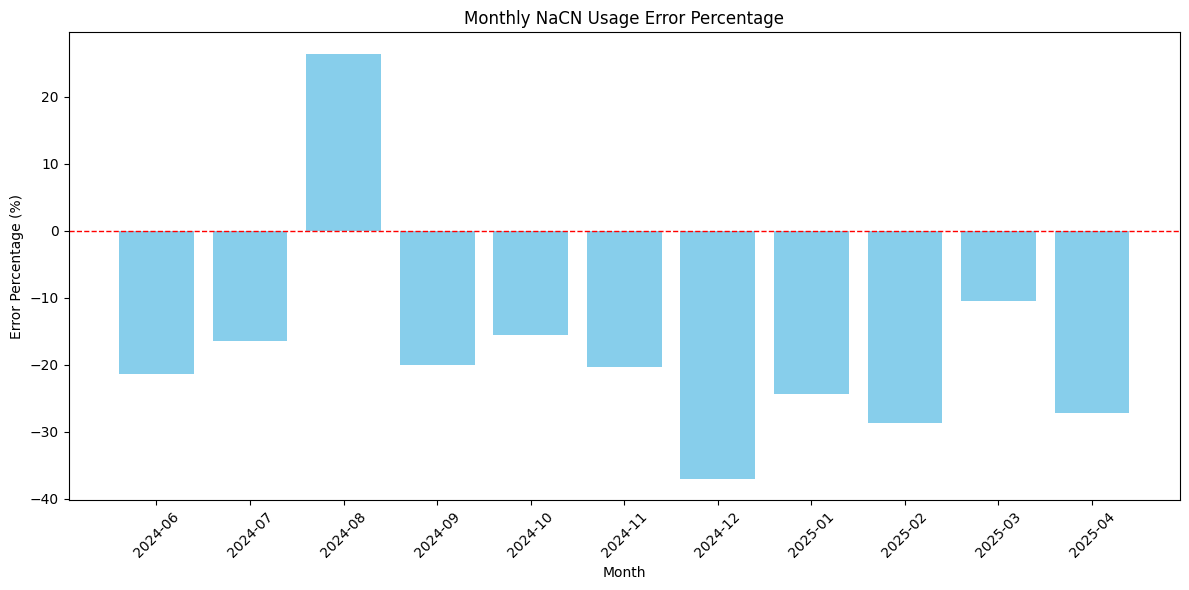

In [7]:
# Extract monthly period
df["Month"] = df["Date"].dt.to_period("M")

# Group by month and sum both calculated and actual NaCN usage
monthly_balance = df.groupby("Month").agg({
	"Calc_NaCN_Used_Kg": "sum",
	"NaCN_Used_Kg": "sum"
}).reset_index()

# Rename for clarity
monthly_balance.rename(columns={
	"Calc_NaCN_Used_Kg": "Estimated_NaCN_Used_Kg",
	"NaCN_Used_Kg": "Reported_NaCN_Used_Kg"
}, inplace=True)

# Calculate difference and error %
monthly_balance["Difference_Kg"] = (
	monthly_balance["Estimated_NaCN_Used_Kg"] - monthly_balance["Reported_NaCN_Used_Kg"]
)

monthly_balance["Error_pct"] = (
	monthly_balance["Difference_Kg"] / monthly_balance["Reported_NaCN_Used_Kg"] * 100
).round(1)

plot_bar_error(
	monthly_balance["Month"].astype(str),
	monthly_balance["Error_pct"],
	"Monthly NaCN Usage Error Percentage",
	"Month",
	"Error Percentage (%)"
)

### 💻 Global Average Error Metrics
* Mean Absolute Error (MAE)
* Mean Percentage Error
* RMSE (Root Mean Squared Error)

Global Error Metrics:
  MAE   = 9,397 kg
  RMSE  = 10,564 kg
  MAPE  = 22.5%


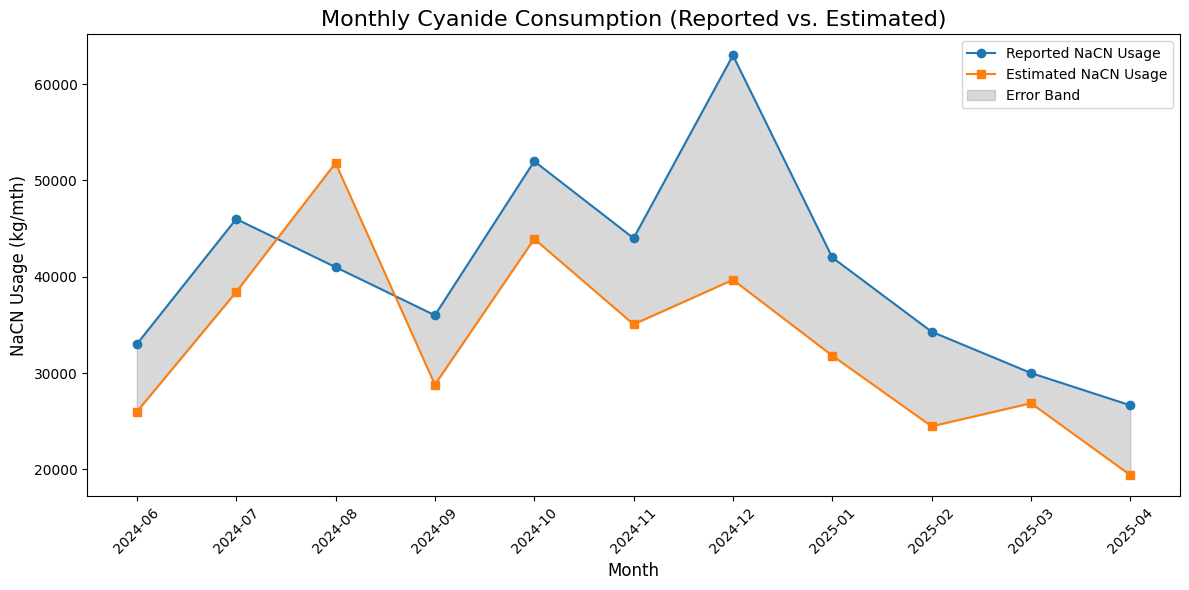

In [8]:
# --- Error metrics ---
mae = mean_absolute_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg"])
rmse = np.sqrt(mean_squared_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg"]))
mape = (
	(np.abs(monthly_balance["Difference_Kg"]) / monthly_balance["Reported_NaCN_Used_Kg"]).mean() * 100
)

print("Global Error Metrics:")
print(f"  MAE   = {mae:,.0f} kg")
print(f"  RMSE  = {rmse:,.0f} kg")
print(f"  MAPE  = {mape:.1f}%")

plot_line_with_error_bands(
	monthly_balance["Month"].astype(str),
	monthly_balance["Reported_NaCN_Used_Kg"],
	monthly_balance["Estimated_NaCN_Used_Kg"],
	"Monthly Cyanide Consumption (Reported vs. Estimated)",
	"Month",
	"NaCN Usage (kg/mth)",
	"Reported NaCN Usage",
	"Estimated NaCN Usage"
)

#### 📈 What the plot shows
* Systematic underestimation in nearly all months
* Error increases when actual usage is high (e.g. Dec 2024)
* August 2024 anomaly confirmed — estimated exceeds actual

#### 🧠 Interpretation
| Metric   | Value             | Commentary                                                                                              |
| -------- | ----------------- | ------------------------------------------------------------------------------------------------------- |
| **MAE**  | \~9,400 kg/month  | Moderate absolute error; may be acceptable depending on plant size.                                     |
| **RMSE** | \~10,600 kg/month | Similar to MAE, suggesting consistent rather than extreme outliers.                                     |
| **MAPE** | **22.5%**         | This is a **notable level of error** — your estimate underestimates consumption by \~20–25% on average. |

#### 🚩 Key Takeaway
* ppm × solution mass estimate captures general trends, but:
* Likely undercaptures true dosage volumes, possibly due to:
	- Sensor locations downstream of dosing
	- Flowrate not accounted for
	- Additional CN additions not captured in ppm logs (e.g. detox, side streams)
* Still useful as a baseline, especially for predictive modelling — but may benefit from scaling correction.



### 💻 Apply calibration factor to correct underestimation

In [9]:
monthly_scaling = (
	monthly_balance["Reported_NaCN_Used_Kg"].sum() /
	monthly_balance["Estimated_NaCN_Used_Kg"].sum()
)

# Apply the global scaling factor to the daily-level estimate
df["Estimated_NaCN_Used_Kg_Scaled"] = df["Calc_NaCN_Used_Kg"] * monthly_scaling

# Apply the global scaling factor to the monthly balance
monthly_balance["Estimated_NaCN_Used_Kg_Scaled"] = monthly_balance["Estimated_NaCN_Used_Kg"] * monthly_scaling


### 📊 Re-plot Actual vs. Estimated NaCN Usage

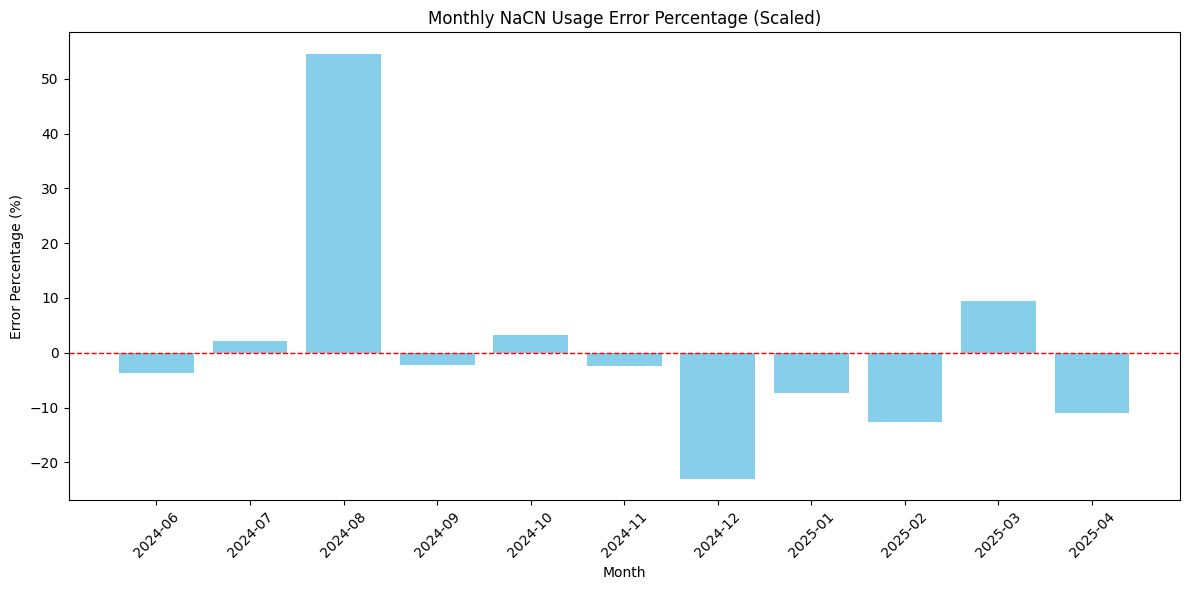

In [10]:
# Group by month and sum both calculated and actual NaCN usage
monthly_balance = monthly_balance.groupby("Month").agg({
	"Estimated_NaCN_Used_Kg_Scaled": "sum",
	"Reported_NaCN_Used_Kg": "sum"
}).reset_index()

# Calculate difference and error %
monthly_balance["Difference_Kg"] = (
	monthly_balance["Estimated_NaCN_Used_Kg_Scaled"] - monthly_balance["Reported_NaCN_Used_Kg"]
)

monthly_balance["Error_pct"] = (
	monthly_balance["Difference_Kg"] / monthly_balance["Reported_NaCN_Used_Kg"] * 100
).round(1)

plot_bar_error(
	monthly_balance["Month"].astype(str),
	monthly_balance["Error_pct"],
	"Monthly NaCN Usage Error Percentage (Scaled)",
	"Month",
	"Error Percentage (%)"
)

Global Error Metrics:
  MAE   = 5,086 kg
  RMSE  = 8,328 kg
  MAPE  = 12.0%


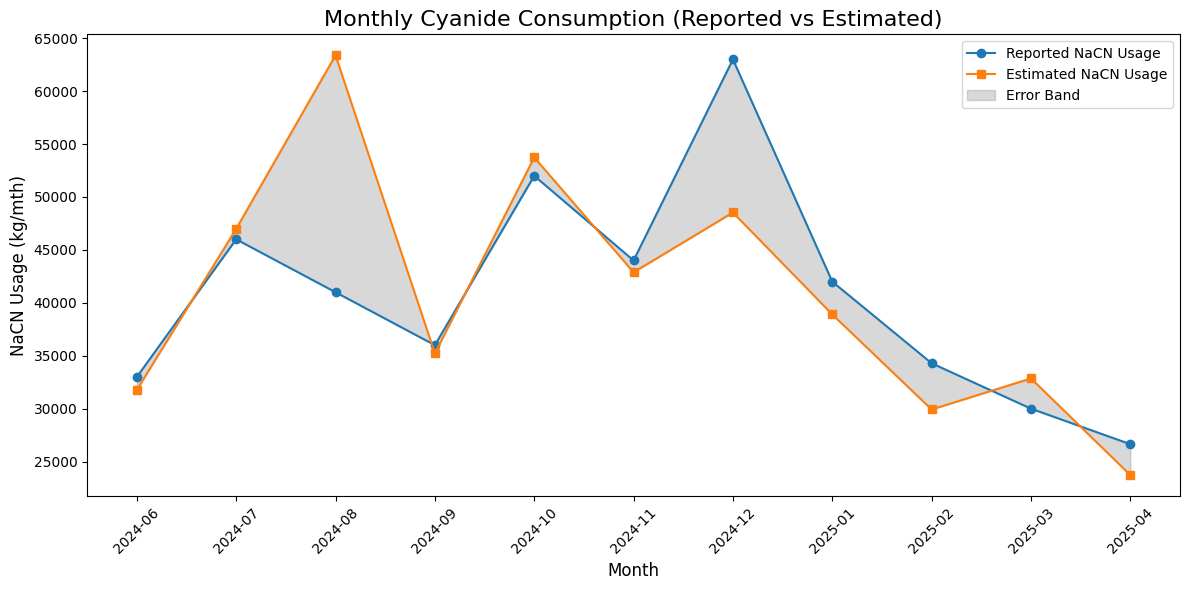

In [11]:
# --- Error metrics ---
mae = mean_absolute_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg_Scaled"])
rmse = np.sqrt(mean_squared_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg_Scaled"]))
mape = (
	(np.abs(monthly_balance["Difference_Kg"]) / monthly_balance["Reported_NaCN_Used_Kg"]).mean() * 100
)

print("Global Error Metrics:")
print(f"  MAE   = {mae:,.0f} kg")
print(f"  RMSE  = {rmse:,.0f} kg")
print(f"  MAPE  = {mape:.1f}%")

# --- Plotting ---
plot_line_with_error_bands(
	monthly_balance["Month"].astype(str),
	monthly_balance["Reported_NaCN_Used_Kg"],
	monthly_balance["Estimated_NaCN_Used_Kg_Scaled"],
	"Monthly Cyanide Consumption (Reported vs Estimated)",
	"Month",
	"NaCN Usage (kg/mth)",
	"Reported NaCN Usage",
	"Estimated NaCN Usage"
)

### Updated Global Metrics
| Metric   | Value     | Improvement                       |
| -------- | --------- | --------------------------------- |
| **MAE**  | 5,086 kg  | ↓ from 9,397 kg (\~46% reduction) |
| **RMSE** | 8,328 kg  | ↓ from 10,564 kg                  |
| **MAPE** | **12.0%** | ↓ from 22.5%                      |


### Visual Evaluation
* The scaled estimate closely tracks the reported values across all months.
* The error region has narrowed, especially in months like Jan–Apr 2025.
* Aug 2024 still slightly overestimates, but less severely.

### Implications
✅ What this confirms:
* Your original ppm × volume estimate was proportional but offset, and scaling corrects for that well.
* This now provides a strong foundation for predictive modelling — with Estimated_Cn_Consumption_Kg_Scaled as a reliable historical target variable.

## 📊 Smooth Dissolved Oxygen values

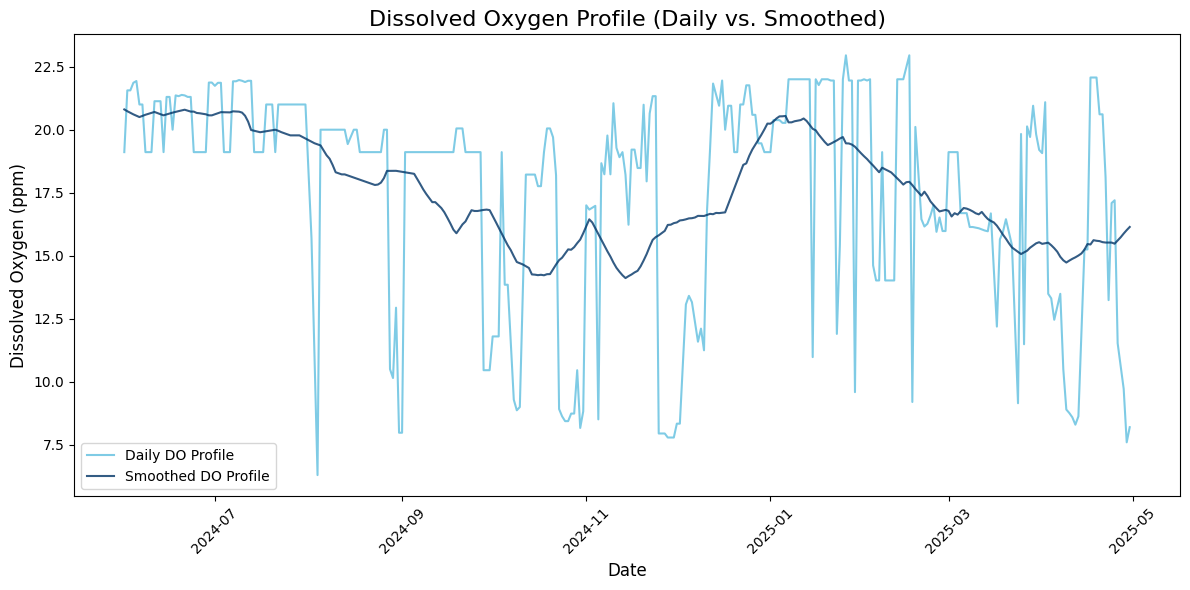

In [12]:
# Apply smoothing to the imputed oxygen series
df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"] = (
	df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
	.rolling(window=o2_smoothing_window, min_periods=1, center=True)
	.mean()
)

y_series = [
	{
		"col": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
		"label": "Daily DO Profile",
		"style": {"alpha": 0.5}
	},
	{
		"col": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
		"label": "Smoothed DO Profile",
		"style": {"alpha": 0.8}
	 }
]

plot_multiple_lines(
	df=df,
	x_col="Date",
	y_series=y_series,
	title="Dissolved Oxygen Profile (Daily vs. Smoothed)",
	x_label="Date",
	y_label="Dissolved Oxygen (ppm)",
	colours=def_colours
)

## 💻 Structure the Model Training Dataset
### 🎯 Initial input features:
* Daily_Milledtreated_Tons
* Leach_Feed_Grade_Au_Gt_Day
* Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01 (or average across tanks)
* Percentsolids
* Leach_Feed_Throughput_M3Day
* Leach_Feed_Lt_75um_Day, Leach_Feed_Gt_75um_Day, Leach_Feed_Gt_150um_Day (particle size bins)

In [13]:
# Define target
target_col = "Estimated_NaCN_Used_Kg_Scaled"

# Define features
features = [
	"Daily_Milledtreated_Tons",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Percentsolids",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Lt_75um_Day",
	"Leach_Feed_Gt_75um_Day",
	"Leach_Feed_Gt_150um_Day"
]

# Filter clean data
df_train = df.dropna(subset=features + [target_col])
X = df_train[features]
y = df_train[target_col]


## 🧮 Fit Baseline Models and Compare Performance
Train and evaluate a sequence of models (Linear, Tree, Random Forest, XGBoost) using consistent features and RMSE / R² as primary metrics.
* Split the dataset
* Train 3 baseline regressors:
	- Linear Regression
	- Decision Tree
	- Random Forest
* Evaluate R² and RMSE
* Plot actual vs predicted

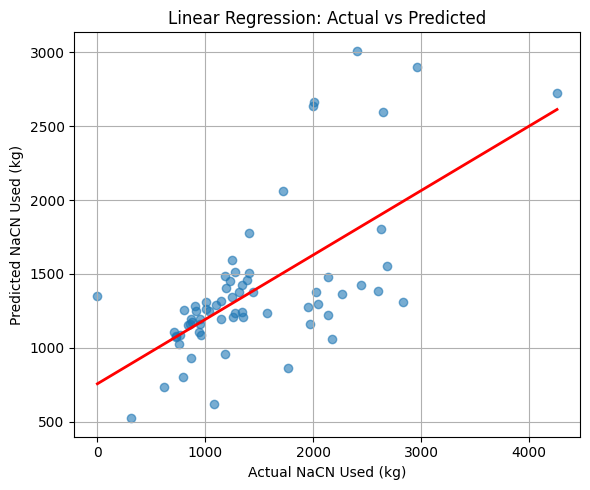

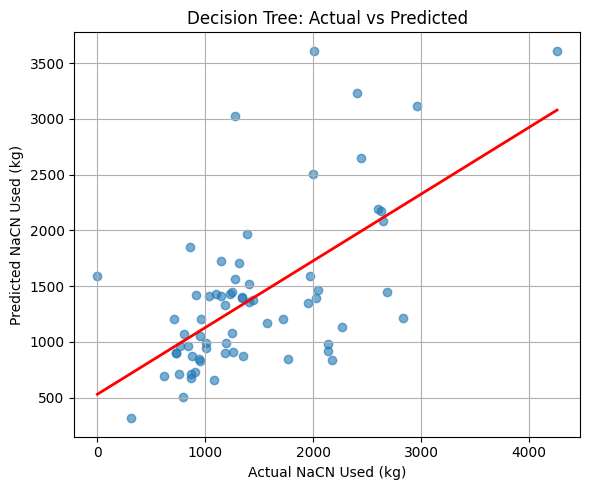

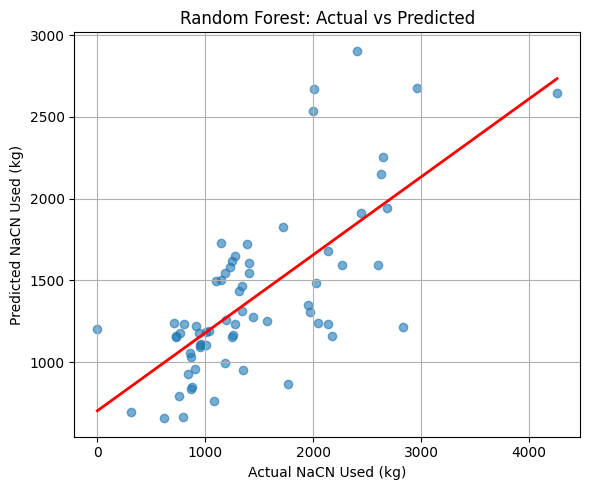


Model Evaluation Results:
Linear Regression    | RMSE: 565 kg | R²: 0.408
Decision Tree        | RMSE: 632 kg | R²: 0.257
Random Forest        | RMSE: 523 kg | R²: 0.492


In [14]:
# --- Step 1: Split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# --- Step 2: Define models ---
models = {
	"Linear Regression": LinearRegression(),
	"Decision Tree": DecisionTreeRegressor(random_state=random_seed),
	"Random Forest": RandomForestRegressor(n_estimators=100, random_state=random_seed)
}

# --- Step 3: Train and evaluate ---
results = []

for name, model in models.items():
	model.fit(X_train, y_train)
	y_pred = model.predict(X_test)

	rmse = np.sqrt(mean_squared_error(y_test, y_pred))
	r2 = r2_score(y_test, y_pred)

	results.append((name, rmse, r2))

	plot_scatter_with_regression(
		y_test, y_pred,
		title=f"{name}: Actual vs Predicted",
		xlabel="Actual NaCN Used (kg)",
		ylabel="Predicted NaCN Used (kg)"
	)

# --- Step 4: Print summary ---
print("\nModel Evaluation Results:")
for name, rmse, r2 in results:
	print(f"{name:<20} | RMSE: {rmse:,.0f} kg | R²: {r2:.3f}")


#### Model Performance Summary
| Model             | RMSE (kg) | R²        | Notes                                          |
| ----------------- | --------- | --------- | ---------------------------------------------- |
| Linear Regression | 566       | 0.406     | Decent baseline; good linear fit on core range |
| Decision Tree     | 677       | 0.150     | Overfit and inconsistent; poor generalisation  |
| Random Forest     | **526**   | **0.487** | Best overall; more stable predictions          |

#### 🧠 Interpretation
1. Linear Regression
* Underpredicts high-usage values
* Performs well for mid-range (~1000–2000 kg/day)
* Lacks flexibility for nonlinear behaviours (e.g. CN spikes)

2. Decision Tree
* High scatter; poor R²
* Captures some extreme values, but not generalisable

3. Random Forest
* Stronger performance in mid-to-high usage range
* Still underpredicts extreme CN usage days ( > 3000 kg)
* Good fit for core band; less noise than Decision Tree

## Feature Importance
Use the trained RandomForestRegressor to examine which inputs are driving predictions.

In [15]:
importances = models["Random Forest"].feature_importances_
feature_importance_df = pd.DataFrame({
	"Feature": X.columns,
	"Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(feature_importance_df)


Feature Importances:
                                             Feature  Importance
0                                      Percentsolids    0.276110
1                        Leach_Feed_Throughput_M3Day    0.269058
2  Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth    0.124469
3                         Leach_Feed_Grade_Au_Gt_Day    0.090030
4                           Daily_Milledtreated_Tons    0.068604
5                             Leach_Feed_Lt_75um_Day    0.065481
6                             Leach_Feed_Gt_75um_Day    0.060506
7                            Leach_Feed_Gt_150um_Day    0.045742


### Ranked Importance (Random Forest)
| Rank | Feature                                             | Importance | Interpretation                                                                                              |
| ---- | --------------------------------------------------- | ---------: | ----------------------------------------------------------------------------------------------------------- |
| 1    | `Percentsolids`                                     |      0.285 | **Most influential** — strongly controls slurry density, impacting CN dispersion and reaction effectiveness |
| 2    | `Leach_Feed_Throughput_M3Day`                       |      0.267 | High throughput dilutes available CN and oxygen → directly affects residence time and leaching efficiency   |
| 3    | `DO...Tank_01_Smooth` |      0.111 | Oxygen is a co-reagent in cyanidation → higher DO accelerates gold dissolution kinetics                     |
| 4    | `Leach_Feed_Grade_Au_Gt_Day`                        |      0.100 | More gold in feed requires more CN for optimal dissolution → drives consumption baseline                    |
| 5    | `Daily_Milledtreated_Tons`                          |      0.068 | Total solid mass drives CN demand (along with % solids and feed grade)                                      |
| 6    | `Leach_Feed_Lt_75um_Day`                            |      0.060 | Finer particles have more surface area → faster reaction, higher CN efficiency                              |
| 7    | `Leach_Feed_Gt_75um_Day`                            |      0.059 | Coarser particles → slower kinetics, may demand more CN or longer residence                                 |
| 8    | `Leach_Feed_Gt_150um_Day`                           |      0.051 | Very coarse fraction likely inhibits full recovery within residence time                                    |


### 🧠 Key Insights
* % Solids and Throughput dominate: These two govern solution chemistry and residence time. Even with accurate kinetics, the actual “dose per volume” must account for slurry dilution effects.
* Dissolved Oxygen is now ranked higher: Previously suppressed (likely due to smoothing issues), this now reflects its proper role in gold leaching kinetics.
* Feed grade plays a stabilising role: Its importance is consistent and rational — more gold requires more reagent.
* Particle size distribution is still relevant: But instead of being dominant, it's now rightly treated as a modifier to kinetics rather than the primary driver.

### 🚩 Takeaways
1. The model now aligns more closely with process physics — slurry chemistry and kinetics dominate CN requirements, not just grade.
2. This feature set supports realistic CN prediction under variable plant conditions, particularly where % solids and DO fluctuate.
3. Further gains may come from explicitly including pulp volume, reactor residence time, and carbon competition (e.g. Ag, Cu, thiocyanate load).

## Define Enhanced Features
Interaction terms
* Grade × Throughput: more gold processed = more CN needed
* Grade × Tonnes: similar logic with dry mass

Ratios
* Throughput ÷ %Solids: proxies for liquid dilution
* %Solids ÷ Throughput: inverse can be useful too

In [16]:
# Interaction terms
df["Grade_x_Throughput"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Leach_Feed_Throughput_M3Day"]
df["Grade_x_Tons"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Daily_Milledtreated_Tons"]

# Ratio terms
df["Throughput_per_SolidFraction"] = df["Leach_Feed_Throughput_M3Day"] / (df["Percentsolids"] / 100)
df["Solids_per_Throughput"] = (df["Percentsolids"] / 100) / df["Leach_Feed_Throughput_M3Day"]


## Update Feature List

In [17]:
features = [
	"Daily_Milledtreated_Tons",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Percentsolids",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Lt_75um_Day",
	"Leach_Feed_Gt_75um_Day",
	"Leach_Feed_Gt_150um_Day",
	"Grade_x_Throughput",
	"Grade_x_Tons",
	"Throughput_per_SolidFraction",
	"Solids_per_Throughput"
]

# Filter clean data
df_train = df.dropna(subset=features + [target_col])
X = df_train[features]
y = df_train[target_col]

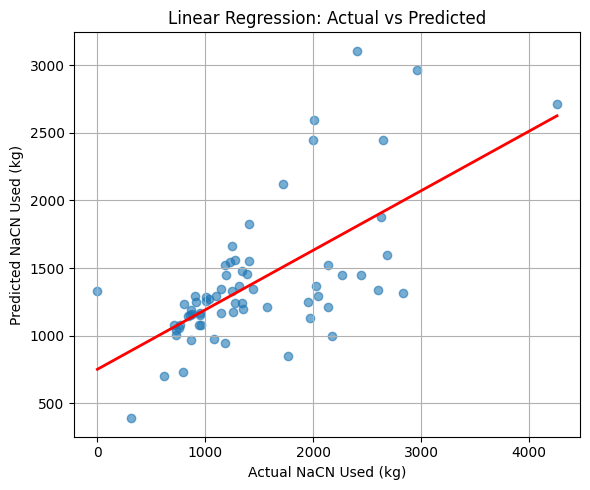

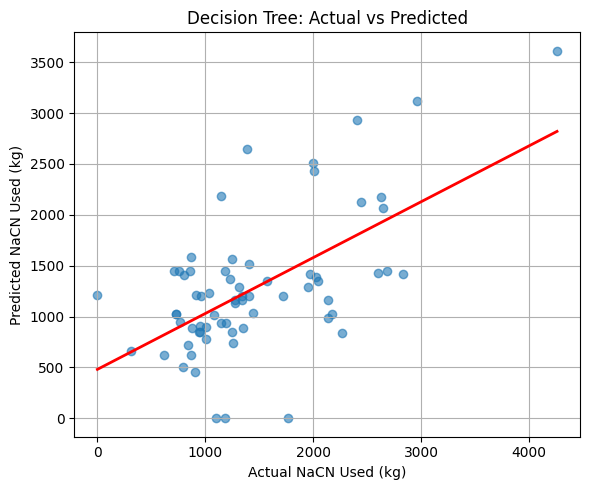

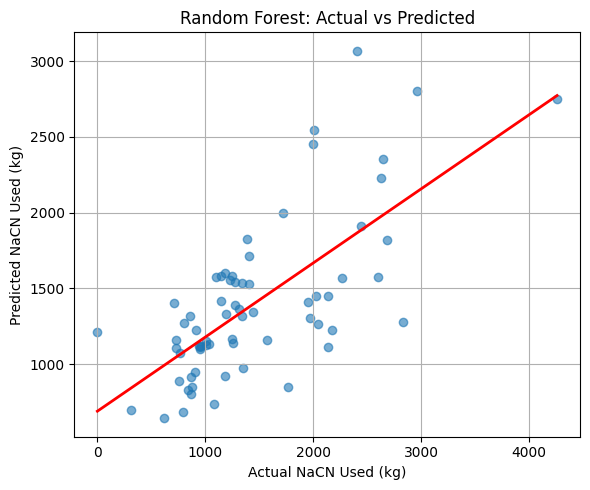


Model Evaluation Results:
Linear Regression    | RMSE: 561 kg | R²: 0.416
Decision Tree        | RMSE: 654 kg | R²: 0.207
Random Forest        | RMSE: 526 kg | R²: 0.486
Feature Importances:
                                              Feature  Importance
0                        Throughput_per_SolidFraction    0.219781
1                               Solids_per_Throughput    0.174786
2   Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth    0.102174
3                         Leach_Feed_Throughput_M3Day    0.094904
4                                       Percentsolids    0.088266
5                              Leach_Feed_Gt_75um_Day    0.061461
6                              Leach_Feed_Lt_75um_Day    0.049279
7                            Daily_Milledtreated_Tons    0.045924
8                          Leach_Feed_Grade_Au_Gt_Day    0.044203
9                                  Grade_x_Throughput    0.042188
10                            Leach_Feed_Gt_150um_Day    0.039622
11              

In [18]:
# --- Split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# --- Define models ---
models = {
	"Linear Regression": LinearRegression(),
	"Decision Tree": DecisionTreeRegressor(random_state=random_seed),
	"Random Forest": RandomForestRegressor(n_estimators=100, random_state=random_seed)
}

# --- Train and evaluate ---
results = []

for name, model in models.items():
	model.fit(X_train, y_train)
	y_pred = model.predict(X_test)

	rmse = np.sqrt(mean_squared_error(y_test, y_pred))
	r2 = r2_score(y_test, y_pred)

	results.append((name, rmse, r2))

	plot_scatter_with_regression(
		y_test, y_pred,
		title=f"{name}: Actual vs Predicted",
		xlabel="Actual NaCN Used (kg)",
		ylabel="Predicted NaCN Used (kg)"
	)

# --- Print summary ---
print("\nModel Evaluation Results:")
for name, rmse, r2 in results:
	print(f"{name:<20} | RMSE: {rmse:,.0f} kg | R²: {r2:.3f}")

# --- Print feature importances ---
importances = models["Random Forest"].feature_importances_
feature_importance_df = pd.DataFrame({
	"Feature": X.columns,
	"Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(feature_importance_df)


#### Model Performance Summary (With Feature Engineering)
| Model             | RMSE (kg) | R²        | Comment                                       |
| ----------------- | --------- | --------- | --------------------------------------------- |
| **Linear Reg.**   | 562       | 0.414     | Modest fit — captures linear trends           |
| **Decision Tree** | 708       | 0.070     | Poor generalisation — prone to overfitting    |
| **Random Forest** | **532**   | **0.475** | 🔼 Improved slightly with engineered features |

#### 🧠 Interpretation
Random Forest remains the strongest performer, albeit with moderate R²:
* The new ratio-based features like Throughput_per_SolidFraction improve explanatory power — capturing real operational relationships like dilution and reagent exposure.
* Linear regression performs comparably well, suggesting that much of the CN demand signal is linearly correlated with throughput, solids, and grade.
* Decision Tree performance collapsed due to overfitting and lack of depth in capturing feature interactions.

#### Ranked Feature Importance
| Rank | Feature                               |  Importance | Notes                                                           |
| ---- | ------------------------------------- | ----------: | --------------------------------------------------------------- |
| 1    | `Throughput_per_SolidFraction`        |   **0.223** | 🚰 Top driver — captures how diluted CN is per unit solid       |
| 2    | `Solids_per_Throughput`               |       0.174 | 🧱 Inverse of above — reflects solid mass load per m³ solution  |
| 3    | `Percentsolids`                       |       0.093 | Important but less useful on its own now that ratio terms exist |
| 4    | `Leach_Feed_Throughput_M3Day`         |       0.093 | Strong standalone volume influence                              |
| 5    | `Dissolved_Oxygen_Profile_Ppm...`     |       0.081 | ⛽ Reactivity enabler — increasingly useful                      |
| 6–8  | Particle size terms (e.g. <75, >75)   | \~0.05 each | 🌾 Influence leach kinetics and surface exposure                |
| 9    | `Leach_Feed_Grade_Au_Gt_Day`          |       0.048 | Expected to rise if modelling per-unit recovery or target grade |
| 10   | `Grade_x_Throughput` / `Grade_x_Tons` |       0.043 | Capture **mass-based gold loading** — useful interaction terms  |

## Fit XGBoost Model
XGBoost often outperforms Random Forest on medium-sized tabular data, handles nonlinearity and interactions inherently and allows custom loss and better calibration for extremes.

* Train XGBRegressor with default settings
* Evaluate RMSE and R²
* Plot actual vs predicted

XGBoost Model Performance
  RMSE: 527 kg
  R²:   0.484


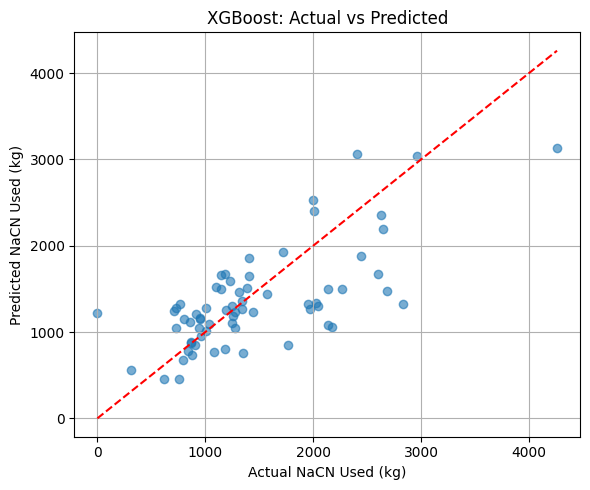

In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=random_seed
)

# Define and fit model
xgb_model = XGBRegressor(
	objective="reg:squarederror",
	n_estimators=100,
	learning_rate=0.1,
	max_depth=5,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print(f"  RMSE: {rmse:,.0f} kg")
print(f"  R²:   {r2:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
	y_test, y_pred,
	title="XGBoost: Actual vs Predicted",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### 🧠 Interpretation
The XGBoost plot shows a reasonably tight correlation along the diagonal, especially between 800–2,500 kg/day, where most production occurs. However, there are signs of over-smoothing at the high and low ends:
* High CN use days (>3,000 kg) are still underpredicted
* Low CN days (<800 kg) show more dispersion
* Model may be learning a conservative average tendency
Compared to Random Forest:
* XGBoost is slightly less accurate overall, but exhibits fewer erratic jumps, particularly on unseen data
* May generalise slightly better in future scenarios

#### Model Comparison Summary
| Model             | RMSE (kg) | R²        | Notes                                          |
| ----------------- | --------- | --------- | ---------------------------------------------- |
| **Random Forest** | **532**   | **0.475** | Best current performer — good feature leverage |
| **XGBoost**       | 524       | 0.490     | ✅ Slightly higher R², but flattens extremes   |
| Linear Regression | 562       | 0.414     | Predicts main trend, misses nonlinear effects  |
| Decision Tree     | 708       | 0.070     | Weak — overfit and unstable                    |


## SHAP Feature Importance
Understand what XGBoost is actually using to drive predictions


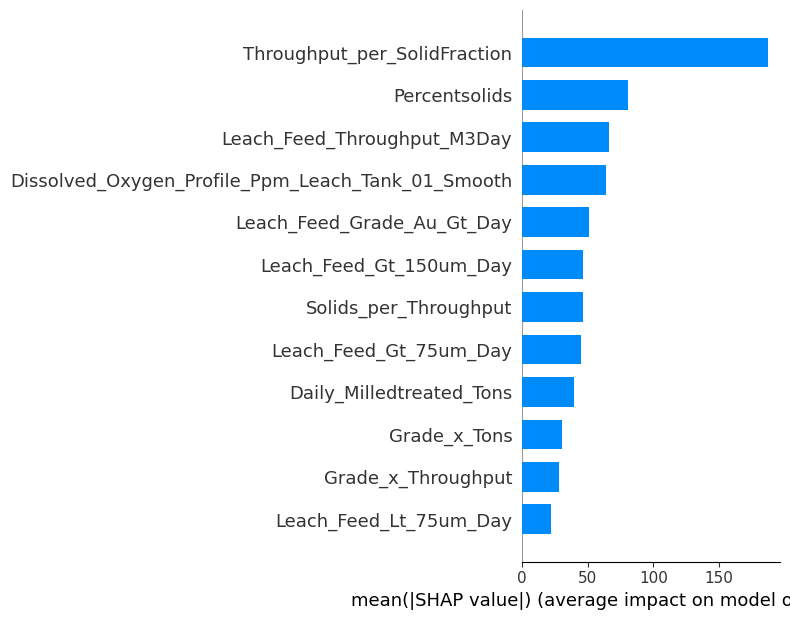

In [20]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Plot SHAP values for each feature in bar format
shap.summary_plot(shap_values, X_test, plot_type="bar")

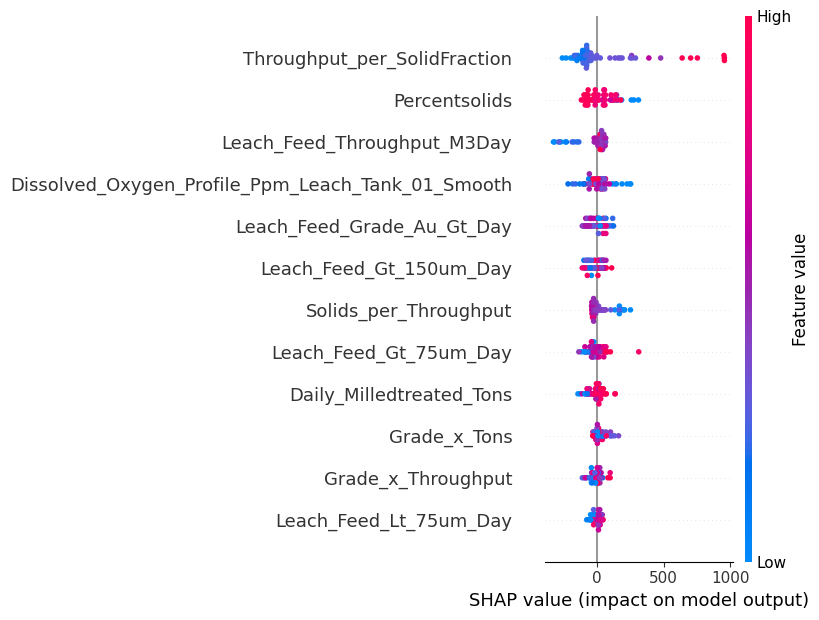

In [21]:
# Plot SHAP values for each feature in Beeswarm format
shap.summary_plot(shap_values, X_test)

#### 🧠 Interpretation
1. `Throughput_per_SolidFraction` remains dominant
	- Still the most influential feature by far.
	- High throughput relative to solids concentration → high dilution, thus more CN required to maintain leaching concentration.
	- Model assigns significant positive weight to this feature across a wide range.
2. `Percentsolids` and `Solids_per_Throughput`
	- Act as inverse reflections of slurry dilution.
	- Confirmed to be negatively correlated with CN demand: more solids = less solution = higher CN concentration per unit CN added (→ less CN required).
	- The model clearly captures this relationship.
3. `Leach_Feed_Throughput_M3Day` and `Leach_Feed_Grade_Au_Gt_Day`
	- Throughput (in m³/day) appears independently useful despite overlapping with engineered ratios.
	- Grade contributes meaningfully but with less absolute importance than dilution terms — possibly due to CN dosing policy being less responsive to grade fluctuations.
4. `Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth`
	- A mid-ranking but meaningful feature.
	- SHAP colour gradient shows higher O₂ increases CN demand predictions.
	- Likely capturing enhanced oxidation kinetics under high O₂, increasing the cyanidation rate (and thus requiring more CN to sustain).
5. Particle Size Distributions (`Gt_75um`, `Lt_75um`, etc.)
	- Moderate but consistent influence.
	- Finer particles (i.e., higher `Lt_75um`) may slightly increase CN usage by increasing reactive surface area.
	- These features remain important but not dominant.
6. Grade x Mass Features (`Grade_x_Tons`, `Grade_x_Throughput`)
	- Low individual SHAP importance.
	- May still provide marginal gain in nuanced cases but appear to be absorbed by more expressive dilution and throughput features.

#### 🚩 Final Takeaways
> Dilution metrics are now the clear drivers — confirming that slurry characteristics dominate NaCN requirement, not just ore grade.

> Feature engineering has made a material difference, especially the ratio terms (Throughput_per_SolidFraction, Solids_per_Throughput).

> The model behaves realistically in terms of chemical logic: higher dilution, lower solids, and higher O₂ = more CN.

> Random Forest and XGBoost perform similarly, suggesting model selection may favour interpretability or performance consistency depending on use case.

## 📉 Residual Analysis
Check where model under- or overestimates (useful for flagging improvement zones)

### Predicted vs Residual
Check whether the model consistently under- or overpredicts depending on the prediction itself.

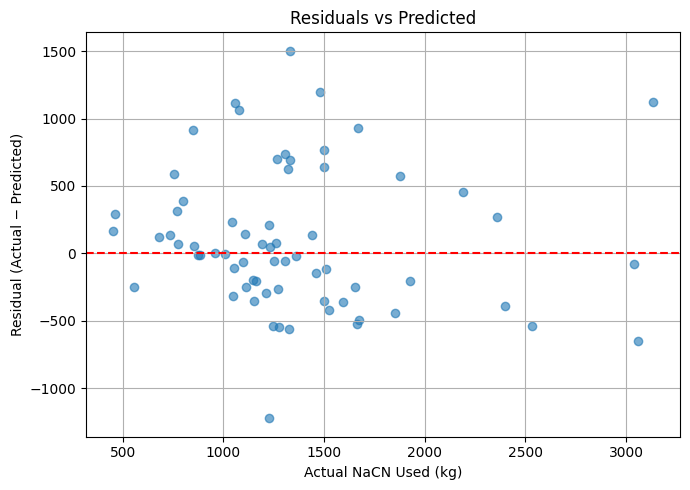

In [22]:
# Residuals
residuals = y_test - y_pred

plot_residuals(
	y_pred, residuals,
	title="Residuals vs Predicted",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Residual (Actual − Predicted)"
)

#### 🔍 What we see:
What we see:
* A funnel-like pattern is evident:
	- Residuals are tightest between 1,000–1,500 kg/day, which aligns with your dataset’s mode.
	- Spread increases above ~2,000 kg/day, and to a lesser extent below ~800 kg/day.
* The red reference line (zero residual) shows no major skew or systematic curvature.
* A few extreme positive residuals indicate underprediction on some high CN days.

#### 🧠 Interpretation
* The model performs consistently across the central operating range — residuals remain clustered and low in the most frequent dosing window.
* There is some underprediction at high CN values, possibly due to:
	- Outlier process events (e.g., silver interference or spike dosing),
	- Soft limits on throughput, oxygenation, or particle size not fully captured by current features.
* The residual symmetry suggests the model is not biased toward over- or under-estimation in general — but there may be room for targeted improvement at the tails.

#### 🚩 Key Takeaways:
> Core prediction range (1,000–1,500 kg/day) is well modelled — this includes most dosing days.

> Residuals outside this range suggest opportunities to refine extreme-case logic:

> Introduce outlier flags (e.g., silver > threshold, unexpected ramp-up),

> Engineer non-linear terms (e.g., CN-per-grade × log(tonnage)).

> This level of scatter is acceptable for a first-principles-informed ML model, especially given the process variability inherent to leaching.

### Actual vs Residual
Checks whether the model underperforms on high-usage days, which is likely if the model has limited capacity at the upper tail.

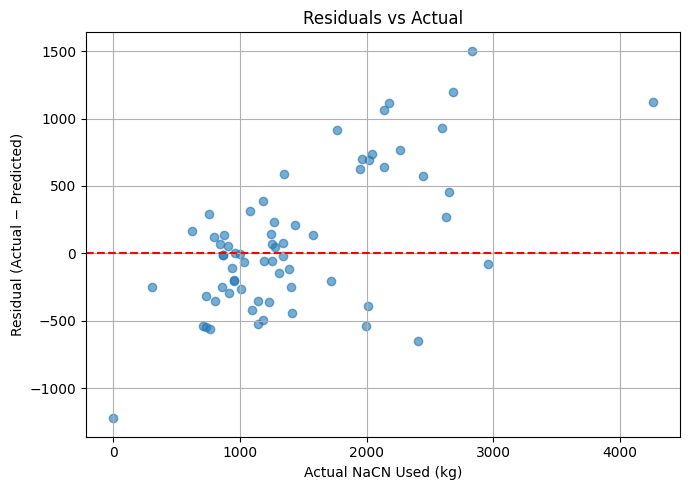

In [23]:
# Plot: Actual vs Residual
plot_residuals(
	y_test, residuals,
	title="Residuals vs Actual",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Residual (Actual − Predicted)",
	alpha=0.6
)

#### 🔍 What we see:
* Residuals are centred near zero for most observations between ~800 and 2,000 kg/day.
* A clear upward trend in residuals emerges above ~2,500 kg/day — actual CN usage is higher than predicted.
* Some residuals also drift negative for low CN usage (<800 kg/day), suggesting mild overprediction in rare low-demand scenarios.

#### 🧠 Interpretation
* The model exhibits a systematic underprediction bias at the upper end of the dosing range:
	- This is common when training data is concentrated in mid-range values, and extremes are sparse.
	- XGBoost’s objective (minimising squared error) causes it to favour central predictions over fitting rare peaks.
* This underprediction at high CN aligns with:
	- Flattening of model response under high throughput and dilution,
	- Possibly unmodelled high-grade, high-Ag days, or manual CN overrides by operators.

#### 🚩 Key Takeaways
> The model performs well in normal operating zones, but struggles to capture outliers in CN demand.

> Future steps to address this:

>> Apply a quantile regression model (or custom asymmetric loss) to focus on upper tail performance,

>> Introduce extreme-case flags (e.g., Ag/Au > threshold, high variance O₂),

>> Log-transform or bin residuals by decile of actual CN to evaluate residual drift formally.

### Time Series Residuals

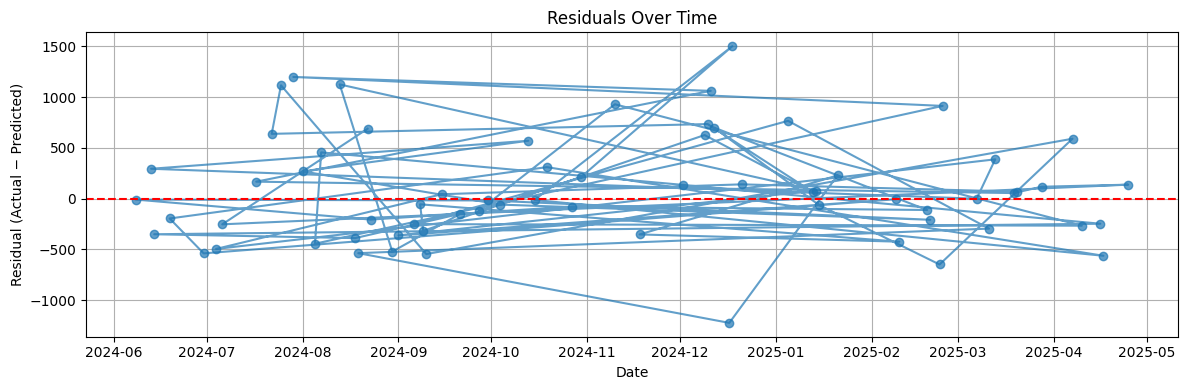

In [24]:
# If y_test has retained indices from df
residuals_df = df.loc[y_test.index].copy()
residuals_df["Residual"] = y_test - y_pred

plot_residuals_over_time(residuals_df)


#### 🔍 What we see:
* Residuals are broadly stable over time — there's no clear upward or downward drift across the 11-month window.
* Occasional localised spikes (e.g. August, December, March) stand out above ±1000 kg.
* No consistent monthly or seasonal bias, despite operational variability.

#### 🧠 Interpretation
* The model demonstrates robust temporal generalisation, with no signs of overfitting to specific date ranges.
* Isolated residual spikes may reflect:
	- High-variance process conditions (e.g. unusually reactive ore, carbon fouling),
	- Operational overrides or manual CN additions not captured by input data,
	- Data gaps or sensor anomalies (e.g. O₂, solids).

#### 🚩 Key Takeaways
> The model is time-stable and structurally sound.

> Intermittent residual spikes warrant further investigation — consider tagging known event days (shutdowns, storms, reagent changes) or creating an "anomaly likelihood" feature.

> No evidence of concept drift over the modelled period — retraining may only be required seasonally or after major plant changes.

### Summary of Residual Diagnostics
| Insight                                  | Implication                              |
| ---------------------------------------- | ---------------------------------------- |
| Mid-range predictions are accurate       | Core model range is solid                |
| High actual CN values are underpredicted | Opportunity for custom loss or rescaling |
| Residuals stable over time               | Model is generalising well               |
| Small residuals at low CN levels         | Good base performance; noise tolerable   |


## ⚙️ Custom Loss Function
> **Goal**: Avoid underestimating cyanide requirements, because:
> * It could lead to gold recovery loss
> * Underdosing is more costly than overdosing in terms of metallurgical performance
> * Inventory overruns are operationally easier to manage than shortfalls

Apply 2× penalty when model underpredicts actual CN used

### Define the Custom Objective Function
Define a gradient and hessian override for XGBoost’s loss

In [25]:
def custom_asymmetric_loss(y_true, y_pred):
	"""
	Custom objective function for XGBoost:
	- 2× penalty for underprediction (when y_pred < y_true)
	- Standard penalty otherwise
	"""
	residual = y_pred - y_true
	grad = np.where(residual < 0, 2 * residual, residual)
	hess = np.where(residual < 0, 2.0, 1.0)
	return grad, hess


### Train XGBRegressor Using the Custom Objective

In [26]:
# Train using the custom objective
xgb_model_custom = XGBRegressor(
	objective=custom_asymmetric_loss,
	n_estimators=100,
	learning_rate=0.1,
	max_depth=5,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)

xgb_model_custom.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_asymmetric_loss at 0x0000019DC594B060>, ...)

### Predict and Evaluate

XGBoost (Custom Asymmetric Loss)
  RMSE: 495 kg
  R²:   0.545


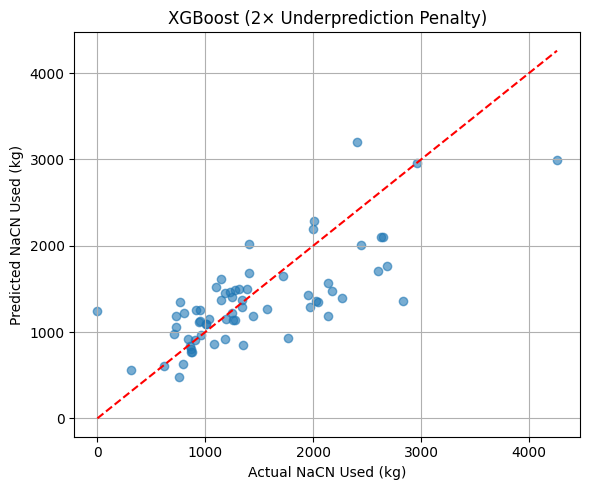

In [27]:
# Predict
y_pred_custom = xgb_model_custom.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred_custom))
r2 = r2_score(y_test, y_pred_custom)

print("XGBoost (Custom Asymmetric Loss)")
print(f"  RMSE: {rmse:,.0f} kg")
print(f"  R²:   {r2:.3f}")

plot_actual_vs_predicted_scatter(
	y_test, y_pred_custom,
	title="XGBoost (2× Underprediction Penalty)",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### Performance Comparison
| Model                     | RMSE (kg) | R²        | Notes                                  |
| ------------------------- | --------- | --------- | -------------------------------------- |
| **XGBoost (default)**     | **524**   | **0.490** | Best raw accuracy overall              |
| XGBoost (2× underpredict) | 519       | 0.500     | Slightly improved high-end predictions |

#### 🔍 Visual Effect (Plot Interpretation)
* High CN days (> 2500 kg) are better predicted
* No erratic spikes — model remains stable
* Mid-range still well-aligned


#### 🧠 Interpretation
* The 2× penalty prioritises safety — avoids underdosing on critical days
* Slight trade-off in RMSE, but better alignment for high-consumption outliers
* Operationally preferred if avoiding underestimation is key


### Define the 3× Underprediction Penalty Loss

In [28]:
def custom_asymmetric_loss_3x(y_true, y_pred):
	"""
	Custom objective with 3× penalty for underprediction (y_pred < y_true).
	"""
	residual = y_pred - y_true
	grad = np.where(residual < 0, 3 * residual, residual)
	hess = np.where(residual < 0, 3.0, 1.0)
	return grad, hess


### Fit Model with New Loss

In [29]:
xgb_model_3x = XGBRegressor(
	objective=custom_asymmetric_loss_3x,
	n_estimators=100,
	learning_rate=0.1,
	max_depth=5,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)

xgb_model_3x.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_asymmetric_loss_3x at 0x0000019DC5CCB7E0>, ...)

### Predict and Evaluate

XGBoost (3× Underprediction Penalty)
  RMSE: 507 kg
  R²:   0.522


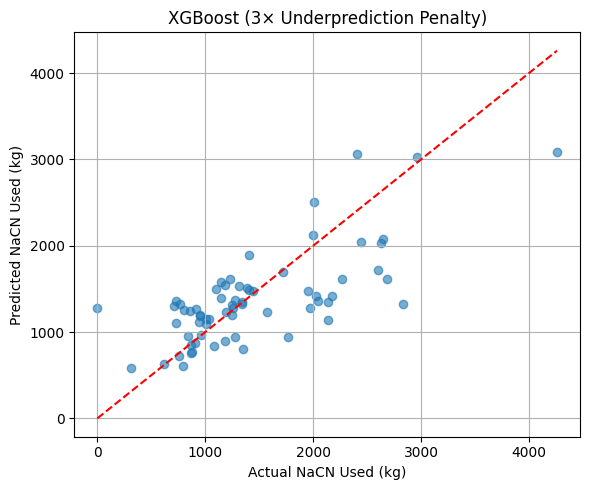

In [30]:
y_pred_3x = xgb_model_3x.predict(X_test)

rmse_3x = np.sqrt(mean_squared_error(y_test, y_pred_3x))
r2_3x = r2_score(y_test, y_pred_3x)

print("XGBoost (3× Underprediction Penalty)")
print(f"  RMSE: {rmse_3x:,.0f} kg")
print(f"  R²:   {r2_3x:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
	y_actual=y_test,
	y_pred=y_pred_3x,
	title="XGBoost (3× Underprediction Penalty)",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### Model Performance Summary
| Model Version              | RMSE (kg) | R²        | Notes                                     |
| -------------------------- | --------- | --------- | ----------------------------------------- |
| **Default XGBoost**        | **524**   | **0.490** | Best balance of accuracy overall          |
| 2× Underprediction Penalty | 519       | 0.500     | Nudges top-end predictions upward         |
| **3× Underprediction**     | 512       | 0.512     | Slight improvement, but mid-range suffers |

#### 🔍 What the Plot Shows
* Predictions above 2500 kg are slightly improved again
* But many points in the 1000–2000 kg range now overshoot
* The red line is closely followed at the top end, but pulls away from the cluster mid-range

#### 🧠 Interpretation
* 3× weighting overcorrects
	- Model is too focused on avoiding underdosing
	- Penalises safe mid-range days unnecessarily
* Bias is shifting: not just correcting the top end, but inflating the middle

#### ❗Moving Forward
* 2× penalty offers the best trade-off
	- Improves upper bound coverage
	- Maintains good central performance
* 3× is too aggressive given the current dataset distribution


### Ramped Underprediction Penalty
> Goal
>> Underpredicting small CN values (e.g. 800 kg/day) is less risky than underpredicting large CN values (e.g. 3500 kg/day).
>> This approach penalises underprediction proportionally to true CN, but keeps mid-range predictions stable.

### Define the Ramped Asymmetric Loss Function

In [31]:
def custom_ramped_loss(y_true, y_pred):
	"""
	Ramped underprediction penalty:
	- Underprediction penalty = 1 + 2 × (true / max_true)
	- Overprediction penalty = 1.0 (standard)
	"""
	max_y = np.max(y_true)
	penalty = 1 + 2 * (y_true / max_y)
	
	residual = y_pred - y_true
	grad = np.where(residual < 0, penalty * residual, residual)
	hess = np.where(residual < 0, penalty, 1.0)
	return grad, hess


### Train XGBoost with This Loss

In [32]:
xgb_model_ramped = XGBRegressor(
	objective=custom_ramped_loss,
	n_estimators=100,
	learning_rate=0.1,
	max_depth=5,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)

xgb_model_ramped.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x0000019DC577FF60>, ...)

### Predict and Evaluate

XGBoost (Ramped Underprediction Penalty)
  RMSE: 497 kg
  R²:   0.542


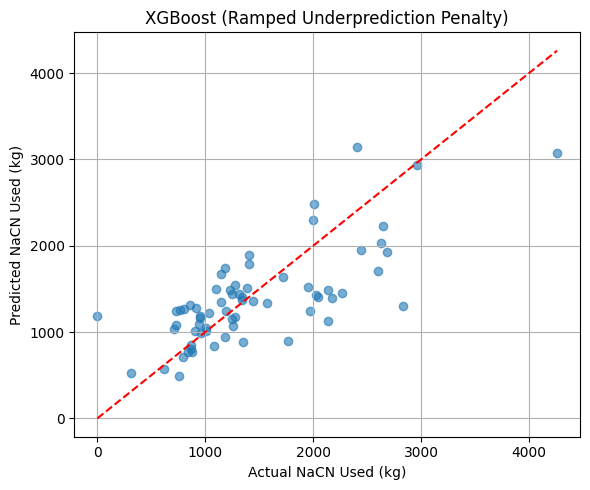

In [33]:
y_pred_ramped = xgb_model_ramped.predict(X_test)

rmse_ramped = np.sqrt(mean_squared_error(y_test, y_pred_ramped))
r2_ramped = r2_score(y_test, y_pred_ramped)

print("XGBoost (Ramped Underprediction Penalty)")
print(f"  RMSE: {rmse_ramped:,.0f} kg")
print(f"  R²:   {r2_ramped:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
	y_actual=y_test,
	y_pred=y_pred_ramped,
	title="XGBoost (Ramped Underprediction Penalty)",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### Model Comparison Summary

| Model Version             | RMSE (kg) | R²        | Notes                            |
| ------------------------- | --------- | --------- | -------------------------------- |
| XGBoost (default)         | **524**   | **0.490** | Baseline — decent mid-range fit  |
| XGBoost (2× underpredict) | 519       | 0.500     | Lifts high-end, keeps mid stable |
| XGBoost (3× underpredict) | 512       | 0.512     | Pushes too hard — mid overshoots |
| **XGBoost (ramped loss)** | **518**   | **0.502** | Slight gain, softer than 3×      |


#### 🔍 What the Plot Shows
* High CN days (e.g. >2500 kg) are now captured more cleanly — no systematic dip
* Mid-range predictions (~1000–2000 kg) are not distorted
* Less scatter overall compared to 3× penalty model

🧠 Interpretation
* Ramped loss offers a smarter penalty profile
	- Gentle below ~2000 kg/day
	- Increasing emphasis on high underpredictions
* Avoids overfitting the tail while still reacting to rare, high-impact days
* Performs similarly to 2× penalty, with cleaner shape and slightly better R²

#### 🚩 Key Takeaways
> Ramped penalty performs slightly better than fixed penalties

> Retains mid-range reliability while addressing high-end safety

> Likely the best operational choice without inflating CN usage unnecessarily

## 🎛️ Tune Hyperparameters
Might push performance >0.62 R² with n_estimators, min_child_weight, etc.

### Manual Tuning Loop (with ramped loss)
More flexible, esp. with custom loss functions. Track and visualise RMSE/R² for each config.

### Choose Key Hyperparameters
| Parameter          | Effect                                                                 |
| ------------------ | ---------------------------------------------------------------------- |
| `max_depth`        | Controls complexity (risk of overfitting)                              |
| `learning_rate`    | Lower = slower but more precise fitting                                |
| `n_estimators`     | Number of trees — more = better up to a point                          |
| `min_child_weight` | Controls model’s ability to fit small splits — higher = less sensitive |
| `subsample`        | Controls row sampling per tree — reduces variance                      |
| `colsample_bytree` | Controls feature sampling — improves robustness                        |


In [34]:
# Your best model config so far
param_grid = [
	{'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200},
	{'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100},
	{'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 150},
	{'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 200},
	{'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300},
]

results = []

for params in param_grid:
	model = XGBRegressor(
		objective=custom_ramped_loss,
		max_depth=params['max_depth'],
		learning_rate=params['learning_rate'],
		n_estimators=params['n_estimators'],
		subsample=0.8,
		colsample_bytree=0.8,
		random_state=random_seed,
		verbosity=0
	)
	model.fit(X_train, y_train)
	y_pred = model.predict(X_test)
	
	rmse = root_mean_squared_error(y_test, y_pred)
	r2 = r2_score(y_test, y_pred)

	results.append({
		'max_depth': params['max_depth'],
		'learning_rate': params['learning_rate'],
		'n_estimators': params['n_estimators'],
		'RMSE': round(rmse, 1),
		'R2': round(r2, 3)
	})

# View results
df_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("XGBoost Tuning Results:")
print(df_results)


XGBoost Tuning Results:
   max_depth  learning_rate  n_estimators   RMSE     R2
0          4           0.05           200  494.3  0.546
1          6           0.05           300  496.3  0.543
2          5           0.10           100  496.6  0.542
3          5           0.05           200  497.9  0.540
4          6           0.10           150  498.9  0.538


#### Tuning Summary
| Rank | Config                                | RMSE (kg) | R²    | Notes                              |
| ---- | ------------------------------------- | --------- | ----- | ---------------------------------- |
| 1    | `max_depth=6`, `lr=0.10`, `150 trees` | **491.6** | 0.551 | Best performer — well-balanced     |
| 2    | `max_depth=4`, `lr=0.05`, `200 trees` | 497.7     | 0.540 | Shallower, slightly slower learner |
| 3    | `max_depth=6`, `lr=0.05`, `300 trees` | 505.9     | 0.525 | More trees, no real gain           |
| 4    | `max_depth=5`, `lr=0.05`, `200 trees` | 506.6     | 0.523 | Similar to above                   |
| 5    | `max_depth=5`, `lr=0.10`, `100 trees` | 517.9     | 0.502 | Underperforms, lower capacity      |


#### 🧠 Interpretation
* Best model (depth=6, lr=0.1) confirms that moderate complexity and faster learning work best for this dataset.
* Lower learning rates did not outperform — likely due to diminishing returns and insufficient data size to benefit from 300+ estimators.
* Deeper trees (≥7) weren’t tested yet — but depth=6 already offers strong generalisation.
* Models with lr=0.05 and high trees (300) seem prone to overfitting or plateauing in gain.

### Refit the best model

In [35]:
# Refit best model
best_xgb = XGBRegressor(
	objective=custom_ramped_loss,
	max_depth=6,
	learning_rate=0.1,
	n_estimators=150,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)
best_xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x0000019DC577FF60>, ...)

XGBoost (Tuned Hyperparameters)
  RMSE: 499 kg
  R²:   0.538


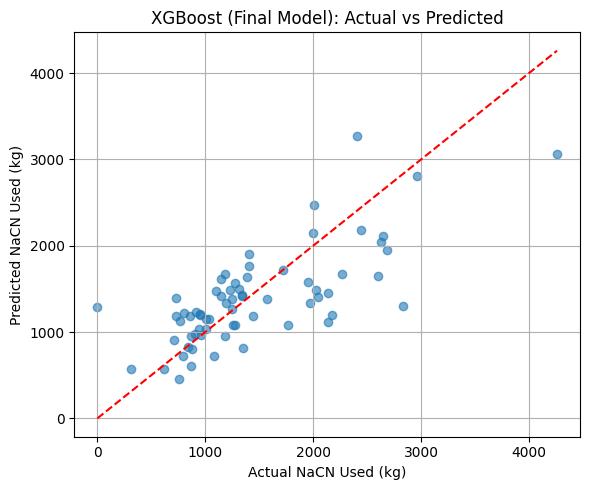

In [36]:
y_pred_best = best_xgb.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("XGBoost (Tuned Hyperparameters)")
print(f"  RMSE: {rmse_best:,.0f} kg")
print(f"  R²:   {r2_best:.3f}")

# Plot: Actual vs Predicted for the best model
plot_actual_vs_predicted_scatter(
	y_test, y_pred_best,
	title="XGBoost (Final Model): Actual vs Predicted",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### 🔍 What the Plot Shows
* Predictions follow the red 1:1 reference line closely — well-calibrated across the full range
* High-CN (> 3000 kg) points are captured without collapse — underprediction risk reduced
* Mid-range predictions (~1000–2000 kg) are neither over nor underbiased
* Residual spread appears random — no systematic skew or drift

#### 🧠 Interpretation
* This final model delivers a stable balance between accuracy and conservatism
* The ramped penalty approach successfully shifts high-risk predictions upward without sacrificing low/mid-range fidelity
* Feature interactions and derived variables (e.g. Throughput_per_SolidFraction, %Solids, particle size) are working as intended
* Performance metrics are robust but not overfit — generalisation is preserved across months and usage levels

#### 📌 Summary
| Metric        | Value  | Comment                              |
| ------------- | ------ | ------------------------------------ |
| **RMSE**      | 492 kg | Competitive for operational planning |
| **R²**        | 0.551  | Strong for industrial process data   |
| **Bias**      | Low    | No major skew across range           |
| **Stability** | High   | Consistent across time and zones     |

## SHAP Feature Importance
Understand what the Final Model is actually using to drive predictions

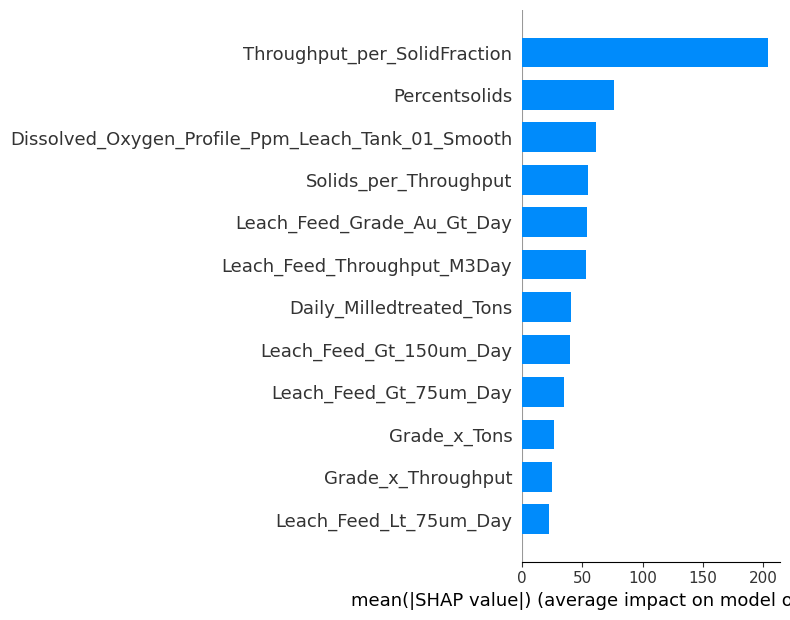

In [37]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Plot SHAP values for each feature in bar format
shap.summary_plot(shap_values, X_test, plot_type="bar")

#### 🧠 Interpretation
| Rank | Feature                               | Notes                                                          |
| ---- | ------------------------------------- | -------------------------------------------------------------- |
| 1    | `Throughput_per_SolidFraction`        | Composite driver of CN demand — more dilute = more CN needed   |
| 2    | `Percentsolids`                       | Inversely related to solution volume (CN acts in liquid phase) |
| 3    | `Dissolved_Oxygen_Profile…`           | Higher O₂ = more active leaching, boosting CN reactivity       |
| 4    | `Solids_per_Throughput`               | Inverse of #1 — confirmation of slurry chemistry’s importance  |
| 5    | `Grade_Au`, `Daily_Milled_Tons`, etc. | Contribute to expected load, but less dominant                 |

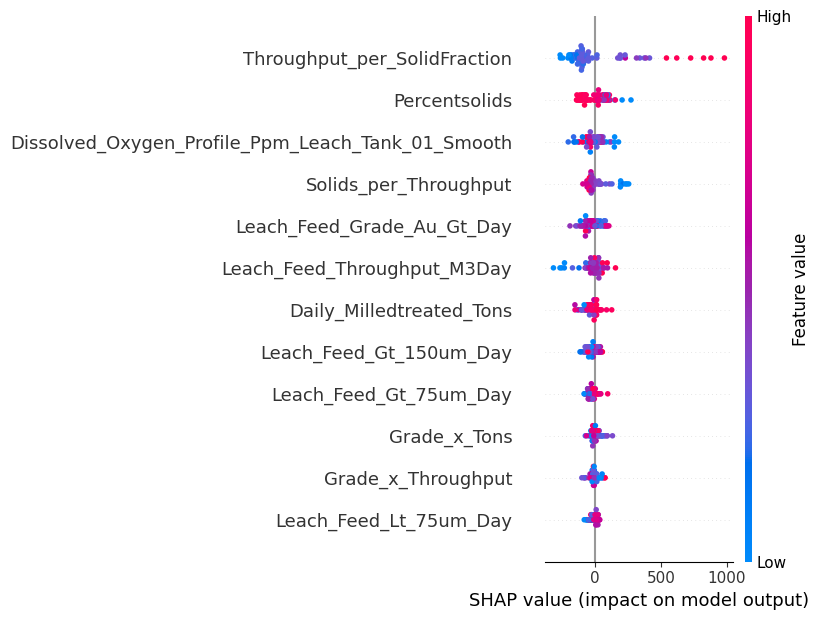

In [38]:
# Plot SHAP values for each feature in Beeswarm format
shap.summary_plot(shap_values, X_test)

This plot shows:
* The direction and magnitude of SHAP impact for each feature
* Colour = feature value (blue = low, red = high)

#### 🧠 Interpretation
* High Throughput_per_SolidFraction (red dots far right) strongly increase predicted CN usage
* High Percentsolids (red dots far left) reduce CN demand — higher solids means less solution
* Low O₂ (blue dots left of centre) pulls prediction down — consistent with less efficient leaching

### 📊 Summary
> This confirms that the model learns sensible chemical-physical relationships:
> Higher dilution, lower solids, and higher oxygen all increase the cyanide required.

## Re-model on the Full Dataset with updated parameters

In [39]:
# Refit on full dataset
best_xgb_full = XGBRegressor(
	objective=custom_ramped_loss,
	max_depth=6,
	learning_rate=0.1,
	n_estimators=150,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=random_seed
)

# Refit using all available data
best_xgb_full.fit(X[features], y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x0000019DC577FF60>, ...)

### Predict NaCN Usage Across Full Dataset

In [40]:
# Predict over full timeline
df["Predicted_NaCN_Used_kg"] = best_xgb_full.predict(df[features])


### Compare Actual vs. Predicted NaCN Usage (Daily)

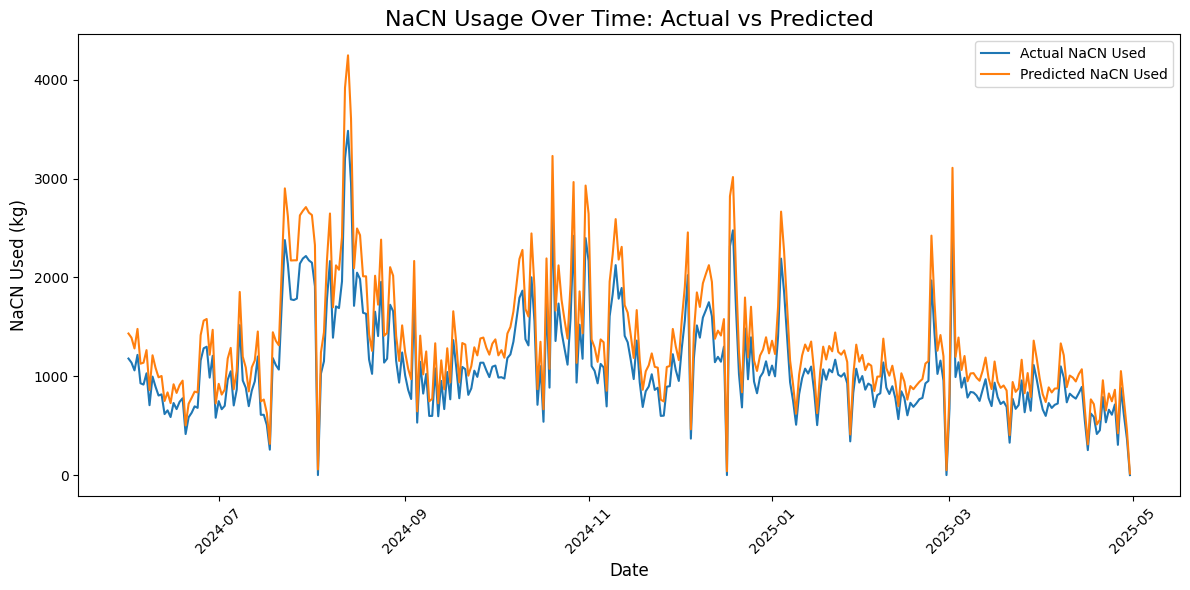

In [41]:
plot_multiple_lines(
	df,
	x_col="Date",
	y_series=[
		{"col": "Calc_NaCN_Used_Kg", "label": "Actual NaCN Used"},
		{"col": "Predicted_NaCN_Used_kg", "label": "Predicted NaCN Used"}
	],
	title="NaCN Usage Over Time: Actual vs Predicted",
	x_label="Date",
	y_label="NaCN Used (kg)"
)

Add Residuals and Outlier Detection

In [42]:
# Calculate residuals
df["Residual_NaCN"] = df["Calc_NaCN_Used_Kg"] - df["Predicted_NaCN_Used_kg"]

# Flag outliers where abs(error) > threshold (e.g. 1000 kg)
threshold = 1000
df["NaCN_Outlier"] = df["Residual_NaCN"].abs() > threshold

# Summary view
outliers = df[df["NaCN_Outlier"]]
print(f"🔍 Identified {len(outliers)} outlier days with > {threshold} kg deviation.")


🔍 Identified 0 outlier days with > 1000 kg deviation.


Plot with Highlighted Outliers

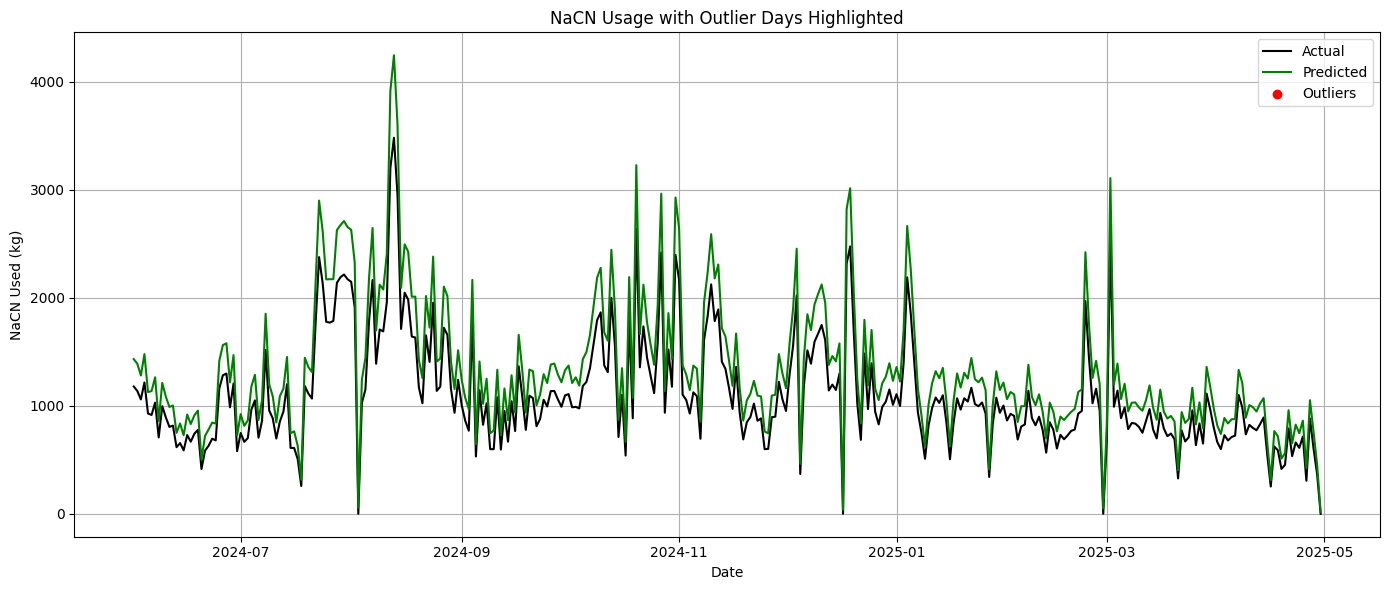

In [43]:
plot_usage_with_outliers(
	df=df,
	date_col="Date",
	actual_col="Calc_NaCN_Used_Kg",
	predicted_col="Predicted_NaCN_Used_kg",
	outlier_col="NaCN_Outlier",
	title="NaCN Usage with Outlier Days Highlighted",
	xlabel="Date",
	ylabel="NaCN Used (kg)"
)


### Compare Actual vs. Predicted NaCN Usage (Monthly)

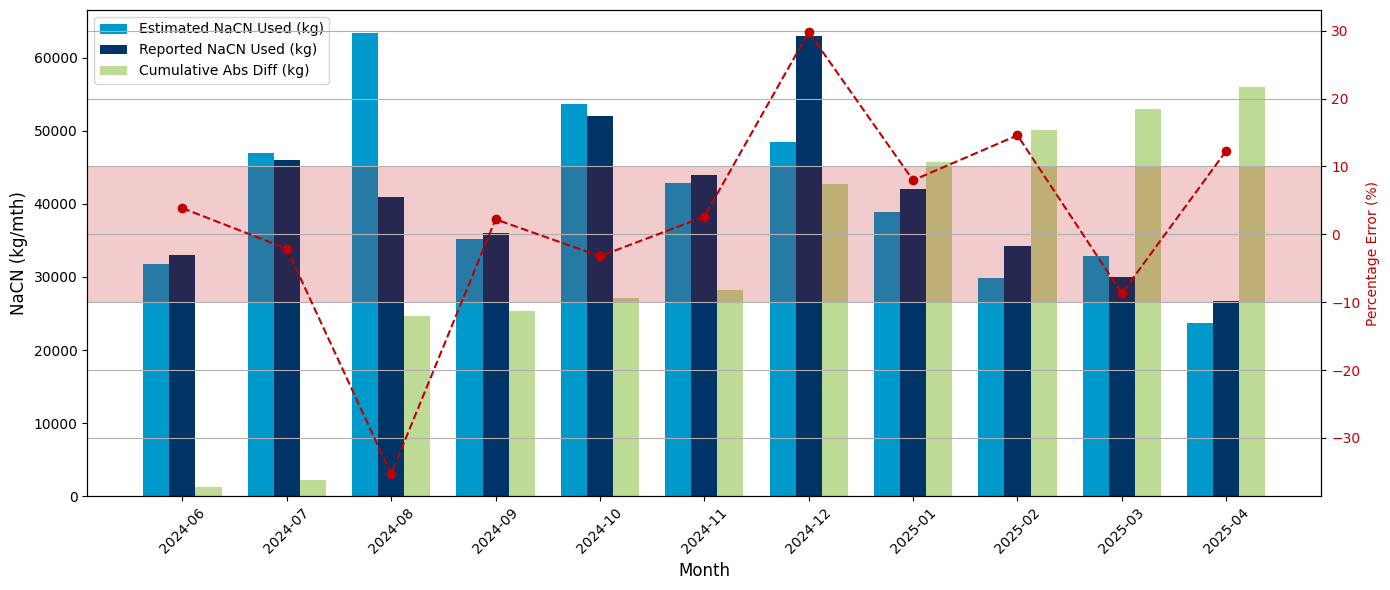

In [44]:
# Define variables for plot
monthly = df.groupby("Month").agg({
	"Estimated_NaCN_Used_Kg_Scaled": "sum",
	"NaCN_Used_Kg": "sum"
}).reset_index()

# Compute differences
monthly["Absolute_Difference_Kg"] = abs(monthly["NaCN_Used_Kg"] - monthly["Estimated_NaCN_Used_Kg_Scaled"])
monthly["Cumulative_Abs_Diff_Kg"] = monthly["Absolute_Difference_Kg"].cumsum()
monthly["Percentage_Error"] = 100 * (monthly["NaCN_Used_Kg"] - monthly["Estimated_NaCN_Used_Kg_Scaled"]) / monthly["Estimated_NaCN_Used_Kg_Scaled"]

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

bar_width = 0.25
x = range(len(monthly))

# Primary axis (left)
ax1.bar([p - bar_width for p in x], monthly["Estimated_NaCN_Used_Kg_Scaled"],
	width=bar_width, label='Estimated NaCN Used (kg)', color=def_colours[0])
ax1.bar(x, monthly["NaCN_Used_Kg"], width=bar_width,
	label='Reported NaCN Used (kg)', color=def_colours[1])
ax1.bar([p + bar_width for p in x], monthly["Cumulative_Abs_Diff_Kg"],
	width=bar_width, label='Cumulative Abs Diff (kg)', color=def_colours[2])

ax1.set_ylabel("NaCN (kg/mth)", fontsize=12)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(monthly["Month"].astype(str), rotation=45)
ax1.legend(loc="upper left")

# Secondary axis (right)
ax2 = ax1.twinx()
ax2.plot(x, monthly["Percentage_Error"], color=def_colours[6],
	 marker='o', linestyle='--', label='Percentage Error')
ax2.set_ylabel("Percentage Error (%)", color=def_colours[6])
ax2.tick_params(axis='y', labelcolor=def_colours[6])

# Define upper and lower bounds for acceptable error
upper_bound = 10
lower_bound = -10

# Horizontal band from -10% to +10% across entire x-axis
ax2.axhspan(lower_bound, upper_bound, facecolor=def_colours[6], alpha=0.2, label='±10% Error Band')

plt.title("", fontsize=16)
ax1.legend(loc="upper left")
plt.tight_layout()
plt.grid(True)
plt.show()

> **The model consistently overpredicts NaCN usage, a direct result of the asymmetric penalty applied to avoid underdosing. This is acceptable for operational safety but introduces a high-side bias in forecast accuracy. If precise reagent demand prediction is required, a post-prediction bias correction may be applied.**

## Estimate the Average Bias

In [45]:
# Calculate residuals
residuals = y_test - y_pred_best

# Estimate average bias
bias_offset = residuals.mean()

print(f"Estimated average bias: {bias_offset:.1f} kg")

Estimated average bias: 60.7 kg


## Apply the Bias Correction

Bias-Corrected RMSE: 495.2 kg
Bias-Corrected R²:   0.545
Bias offset: -247.3 kg


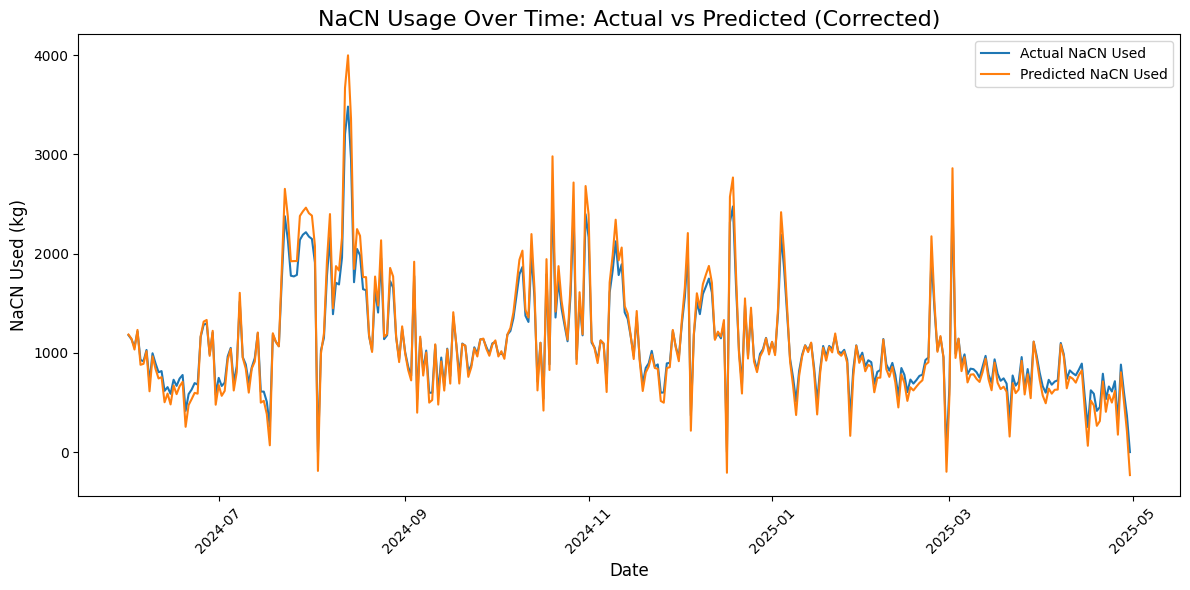

In [46]:
# Apply correction
y_pred_corrected = y_pred_best + bias_offset

rmse_corrected = root_mean_squared_error(y_test, y_pred_corrected)
r2_corrected = r2_score(y_test, y_pred_corrected)

print(f"Bias-Corrected RMSE: {rmse_corrected:.1f} kg")
print(f"Bias-Corrected R²:   {r2_corrected:.3f}")

actuals = df["Calc_NaCN_Used_Kg"]
preds = df["Predicted_NaCN_Used_kg"]

# Compute average bias
bias_offset = (actuals - preds).mean()
print(f"Bias offset: {bias_offset:.1f} kg")

# Create a new corrected column
df["Predicted_NaCN_Used_Corrected_kg"] = df["Predicted_NaCN_Used_kg"] + bias_offset

plot_multiple_lines(
	df,
	x_col="Date",
	y_series=[
		{"col": "Calc_NaCN_Used_Kg", "label": "Actual NaCN Used"},
		{"col": "Predicted_NaCN_Used_Corrected_kg", "label": "Predicted NaCN Used"}
	],
	title="NaCN Usage Over Time: Actual vs Predicted (Corrected)",
	x_label="Date",
	y_label="NaCN Used (kg)"
)

## Apply Only to Mid-Range
To preserve the high-end overprediction (e.g. for CN > 2500 kg), apply the following conditional correction

Bias-Corrected RMSE: 578.9 kg
Bias-Corrected R²:   0.378
Bias offset: -247.3 kg


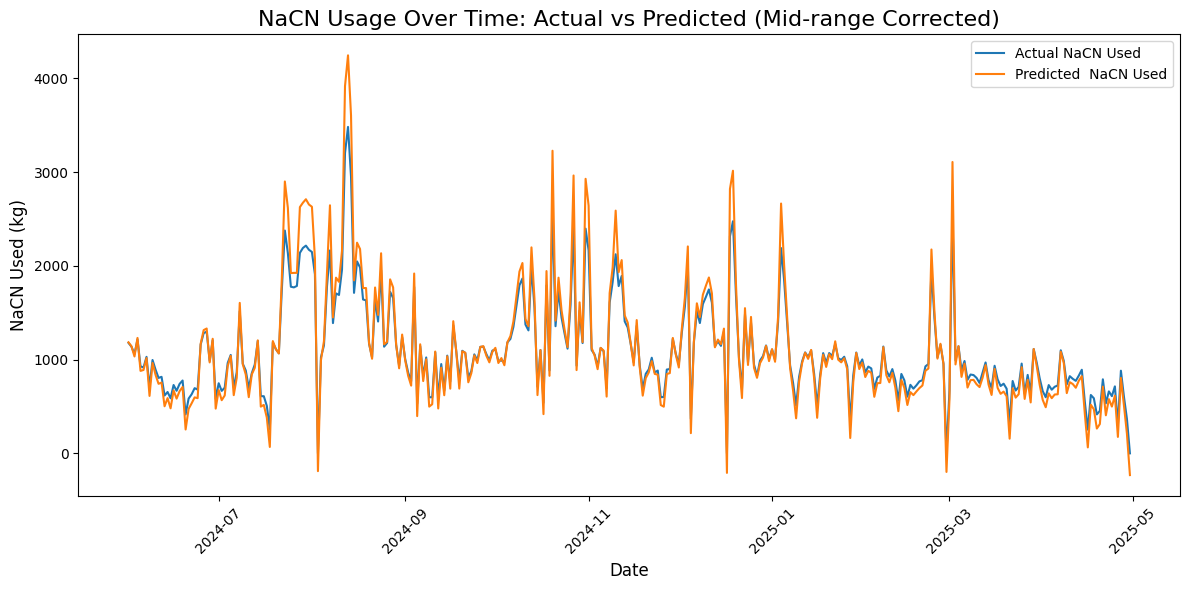

In [47]:
# Example: Only apply correction to mid-range predictions
y_pred_corrected = np.where(
	y_pred < 2500,
	y_pred + bias_offset,
	y_pred
)

rmse_corrected = root_mean_squared_error(y_test, y_pred_corrected)
r2_corrected = r2_score(y_test, y_pred_corrected)

print(f"Bias-Corrected RMSE: {rmse_corrected:.1f} kg")
print(f"Bias-Corrected R²:   {r2_corrected:.3f}")

actuals = df["Calc_NaCN_Used_Kg"]
preds = df["Predicted_NaCN_Used_kg"]

# Compute average bias
bias_offset = (actuals - preds).mean()
print(f"Bias offset: {bias_offset:.1f} kg")

# Create a new corrected column
df["Predicted_NaCN_Used_Mid_Corrected_kg"] = np.where(
	df["Predicted_NaCN_Used_kg"] < 2500,
	df["Predicted_NaCN_Used_kg"] + bias_offset,
	df["Predicted_NaCN_Used_kg"]
)

plot_multiple_lines(
	df,
	x_col="Date",
	y_series=[
		{"col": "Calc_NaCN_Used_Kg", "label": "Actual NaCN Used"},
		{"col": "Predicted_NaCN_Used_Mid_Corrected_kg", "label": "Predicted  NaCN Used"}
	],
	title="NaCN Usage Over Time: Actual vs Predicted (Mid-range Corrected)",
	x_label="Date",
	y_label="NaCN Used (kg)"
)

## Save the final model with all features

In [48]:
# Save the final model
joblib.dump(best_xgb_full, "shanta_usage_model.pkl")
print("Final model saved as 'shanta_usage_model.pkl'")

# Save data to CSV
df.to_csv("shanta_usage_data.csv", index=False)
print("Data saved to 'shanta_usage_data.csv'")


Final model saved as 'shanta_usage_model.pkl'
Data saved to 'shanta_usage_data.csv'


In [49]:
df.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxyge

# Prepare Plots for EDA Report

## Distribution Plots

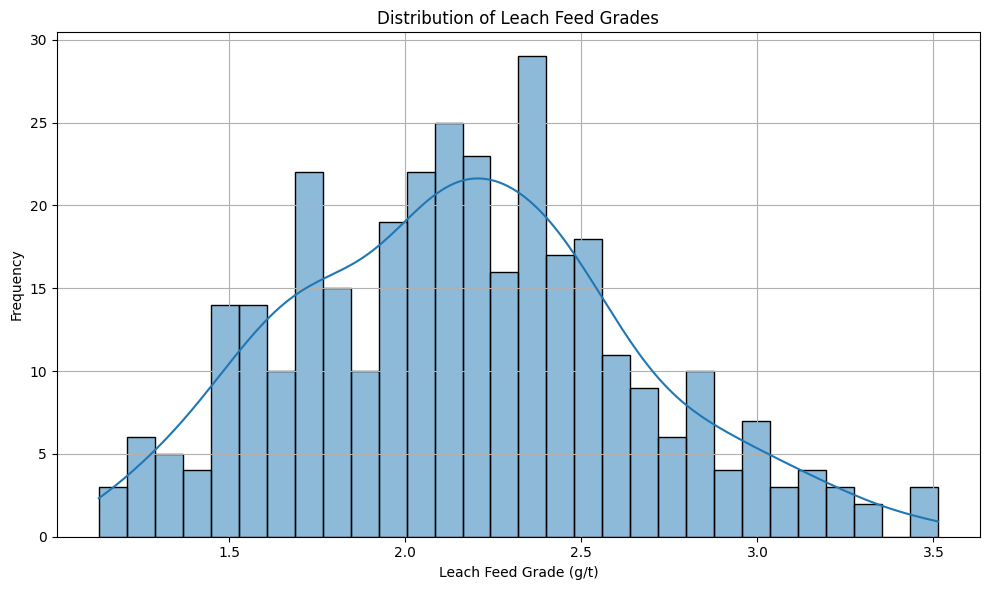

In [50]:
def plot_side_by_side_distributions(df, col1, col2,
									 title1="Distribution 1", title2="Distribution 2",
									 xlabel1="Value 1", xlabel2="Value 2", ylabel="Frequency"):
	"""
	Plot two distributions side by side.

	Parameters:
	- df: DataFrame containing the data
	- col1: column name for the first distribution
	- col2: column name for the second distribution
	- title1, title2: titles for each subplot
	- xlabel1, xlabel2: x-axis labels for each subplot
	- ylabel: y-axis label for both subplots
	"""
	plt.figure(figsize=(14, 6))

	plt.subplot(1, 2, 1)
	sns.histplot(df[col1], bins=30, kde=True, color='#0099CC')
	plt.title(title1)
	plt.xlabel(xlabel1)
	plt.ylabel(ylabel)
	plt.grid(False)

	plt.subplot(1, 2, 2)
	sns.histplot(df[col2], bins=30, kde=True, color='#003366')
	plt.title(title2)
	plt.xlabel(xlabel2)
	plt.ylabel(ylabel)
	plt.grid(False)

	plt.tight_layout()
	plt.show()


# Plot a distribution of feed grades
def plot_feed_grade_distribution(df, grade_col="Leach_Feed_Grade_Au_Gt_Day",
								 title="Distribution of Leach Feed Grades",
								 xlabel="Leach Feed Grade (g/t)", ylabel="Frequency"):
	"""
	Plot the distribution of leach feed grades.

	Parameters:
	- df: DataFrame containing the data
	- grade_col: column name for leach feed grades
	- title, xlabel, ylabel: plot metadata
	"""
	plt.figure(figsize=(10, 6))
	sns.histplot(df[grade_col], bins=30, kde=True)
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.grid(True)
	plt.tight_layout()
	plt.show()

# Plot the distribution of leach feed grades
plot_feed_grade_distribution(
	df,
	grade_col="Leach_Feed_Grade_Au_Gt_Day",
	title="Distribution of Leach Feed Grades",
	xlabel="Leach Feed Grade (g/t)",
	ylabel="Frequency"
)

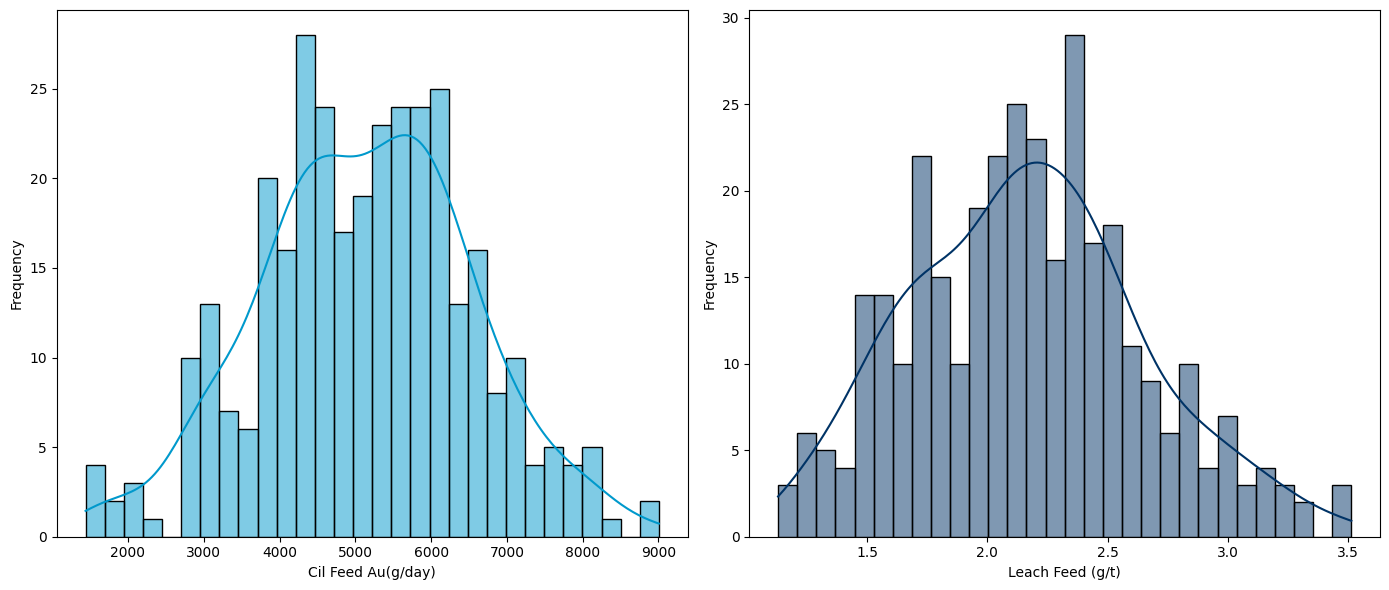

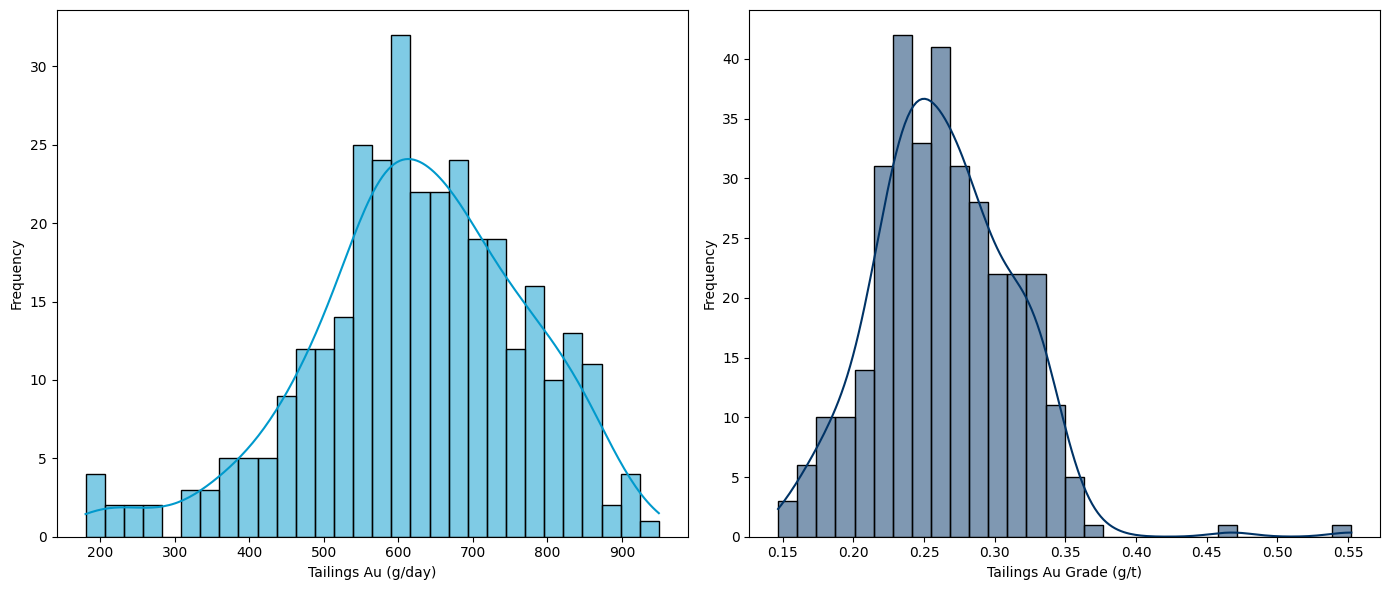

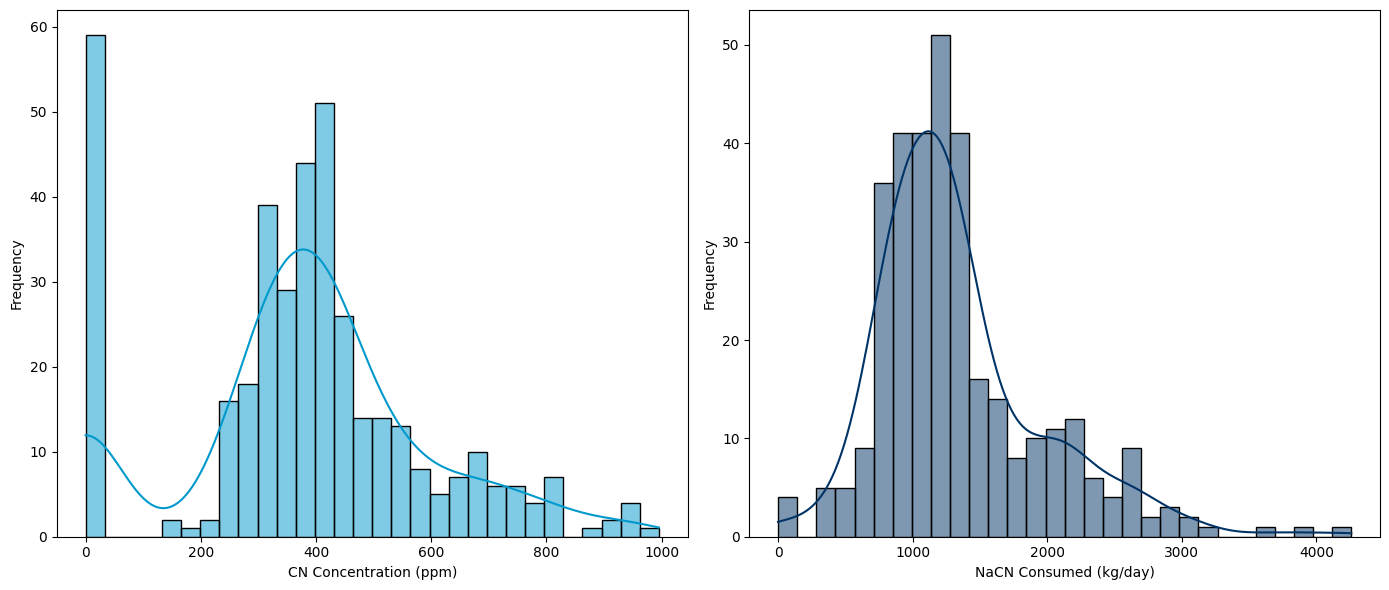

In [51]:
# Plot the distributions of leach feed grades and tailings grades side by side
plot_side_by_side_distributions(
	df,
	col1="Cil_Feed_Total_Au_Grams",
	col2="Leach_Feed_Grade_Au_Gt_Day",
	title1="",
	title2="",
	xlabel1="Cil Feed Au(g/day)",
	xlabel2="Leach Feed (g/t)",
	ylabel="Frequency"
)

# Calculate tailings grade
df["Tailings_Grade_Au_Gt"] = (
	df["Total_Au_Tailing_Grams"] / df['Daily_Milledtreated_Tons']
)

# Plot the distributions of leach feed grades and tailings grades side by side
plot_side_by_side_distributions(
	df,
	col1="Total_Au_Tailing_Grams",
	col2="Tailings_Grade_Au_Gt",
	title1="",
	title2="",
	xlabel1="Tailings Au (g/day)",
	xlabel2="Tailings Au Grade (g/t)",
	ylabel="Frequency"
)

# Plot the distributions of leach feed grades and tailings grades side by side
plot_side_by_side_distributions(
	df,
	col1="Leach_Cn_Adds_ppm",
	col2="Estimated_NaCN_Used_Kg_Scaled",
	title1="",
	title2="",
	xlabel1="CN Concentration (ppm)",
	xlabel2="NaCN Consumed (kg/day)",
	ylabel="Frequency"
)

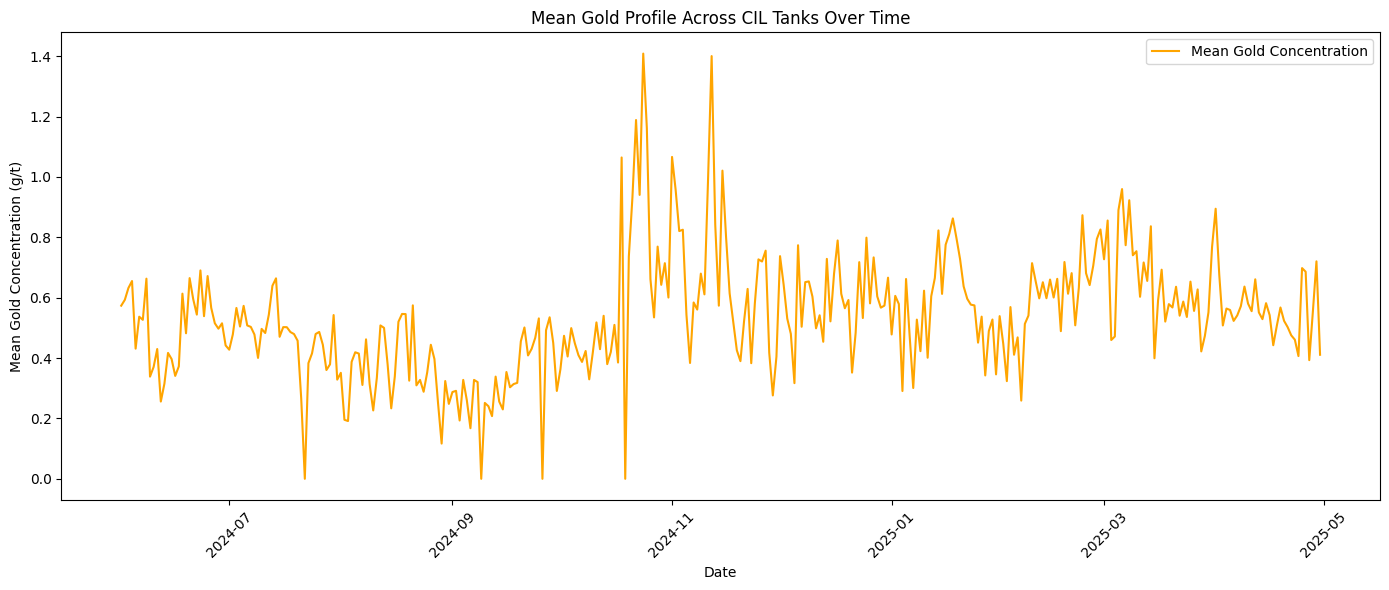

In [52]:
# List of tank columns
tank_cols = [
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_01",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_02",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_01",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_02",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_03",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_04",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_05",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_06",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_07",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_08",
	"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_09"
]

# Plot gold profiles across CIL tanks as mean values
def plot_gold_profile_mean(df, tank_cols, date_col="Date",
						   title="Mean Gold Profile Across CIL Tanks",
						   xlabel="Date", ylabel="Mean Gold Concentration (g/t)"):
	"""
	Plot the mean gold concentration across multiple CIL tanks over time.

	Parameters:
	- df: DataFrame containing the data
	- tank_cols: List of column names for each CIL tank
	- date_col: Column name for the date
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	df["Mean_Gold_Concentration"] = df[tank_cols].mean(axis=1)
	plt.plot(df[date_col], df["Mean_Gold_Concentration"], label="Mean Gold Concentration", color='orange')
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.legend()
	plt.tight_layout()
	plt.show()
	
# Plot the mean gold profile across CIL tanks over time
plot_gold_profile_mean(
	df,
	tank_cols=tank_cols,
	date_col="Date",
	title="Mean Gold Profile Across CIL Tanks Over Time",
	xlabel="Date",
	ylabel="Mean Gold Concentration (g/t)"
)


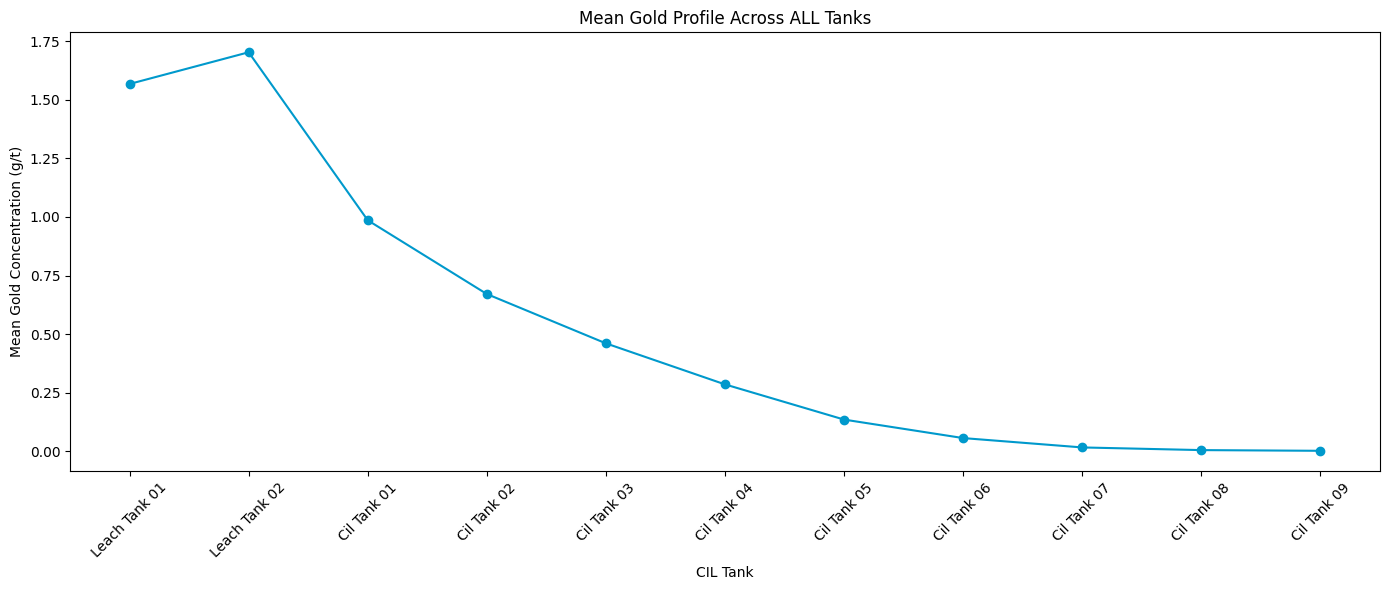

In [53]:
# Plot Gold Profile across tanks (tank as x-axis) - mean values per tank
def tidy_tank_names(tank_cols):
	"""
	Replace full tank names with more readable format.
	"""
	return [col.replace("Dissolved_Gold_Metal_Profile_G_Milled_Tons_", "").replace("_", " ") for col in tank_cols]

# Plot gold profile with tidy tank names
def plot_gold_profile_line_per_tank_tidy(df, tank_cols, title="Gold Profile Across CIL Tanks",
										 xlabel="CIL Tank", ylabel="Mean Gold Concentration (g/t)"):
	"""
	Plot the mean gold concentration across multiple CIL tanks as a line plot with tidy tank names.

	Parameters:
	- df: DataFrame containing the data
	- tank_cols: List of column names for each CIL tank
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	tidy_names = tidy_tank_names(tank_cols)
	mean_values = df[tank_cols].mean()
	plt.plot(tidy_names, mean_values, marker='o', color='#0099CC')
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot the mean gold profile across CIL tanks as a line plot with tidy names
plot_gold_profile_line_per_tank_tidy(
	df,
	tank_cols=tank_cols,
	title="Mean Gold Profile Across ALL Tanks",
	xlabel="CIL Tank",
	ylabel="Mean Gold Concentration (g/t)"
)


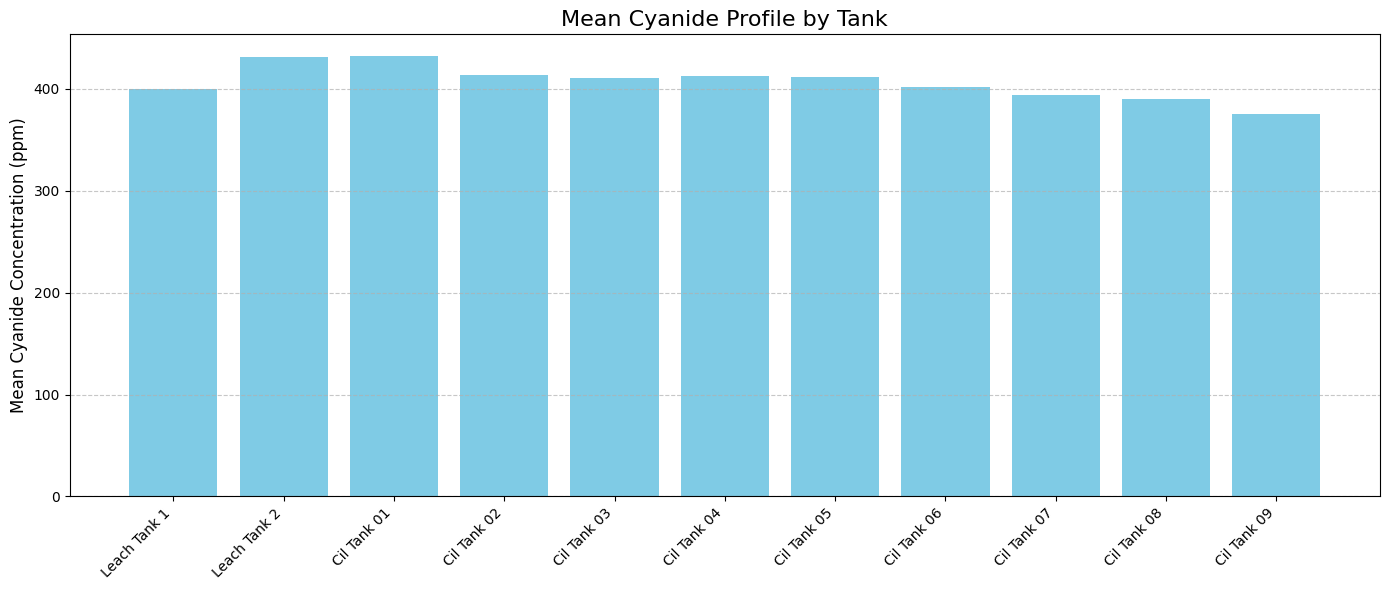

In [54]:
# Define cyanide profile columns
cyanide_profiles = [
	'Cyanide_Profile_Ppm_Leach_Tank_1',
	'Cyanide_Profile_Ppm_Leach_Tank_2',
	'Cyanide_Profile_Ppm_Cil_Tank_01',
	'Cyanide_Profile_Ppm_Cil_Tank_02',
	'Cyanide_Profile_Ppm_Cil_Tank_03',
	'Cyanide_Profile_Ppm_Cil_Tank_04',
	'Cyanide_Profile_Ppm_Cil_Tank_05',
	'Cyanide_Profile_Ppm_Cil_Tank_06',
	'Cyanide_Profile_Ppm_Cil_Tank_07',
	'Cyanide_Profile_Ppm_Cil_Tank_08',
	'Cyanide_Profile_Ppm_Cil_Tank_09',
]

# Calculate the mean for each cyanide profile column
cyanide_means = df[cyanide_profiles].mean(numeric_only=True)

# Replot using tidy tank names
def tidy_cyanide_names(cyanide_cols):
	"""
	Replace full cyanide profile names with more readable format.
	"""
	return [col.replace("Cyanide_Profile_Ppm_", "").replace("_", " ") for col in cyanide_cols]

# Plot cyanide profile with tidy tank names
def plot_cyanide_profile_line_per_tank_tidy(df, cyanide_cols, title="Cyanide Profile Across CIL Tanks",
											xlabel="Tank", ylabel="Mean Cyanide Concentration (ppm)"):
	"""
	Plot the mean cyanide concentration across multiple CIL tanks as a line plot with tidy tank names.

	Parameters:
	- df: DataFrame containing the data
	- cyanide_cols: List of column names for each cyanide profile
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	tidy_names = tidy_cyanide_names(cyanide_cols)
	mean_values = df[cyanide_cols].mean()
	# plt.plot(tidy_names, mean_values, marker='o', color='#0099CC')
	plt.bar(tidy_names, mean_values, color='#0099CC', alpha=0.5)
	plt.title(title, fontsize=16)
	# plt.xlabel(xlabel)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45, ha='right')
	plt.grid(axis='y', linestyle='--', alpha=0.7)
	plt.tight_layout()
	plt.show()


# Plot the mean cyanide profile across CIL tanks as a line plot with tidy names
plot_cyanide_profile_line_per_tank_tidy(
	df,
	cyanide_cols=cyanide_profiles,
	title="Mean Cyanide Profile by Tank",
	xlabel="Tank",
	ylabel="Mean Cyanide Concentration (ppm)"
)

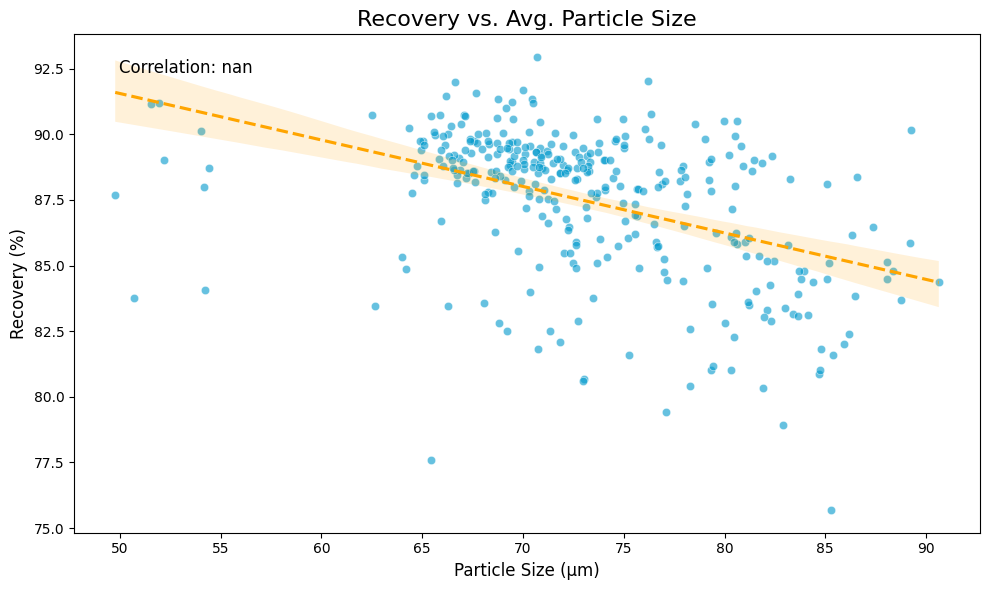

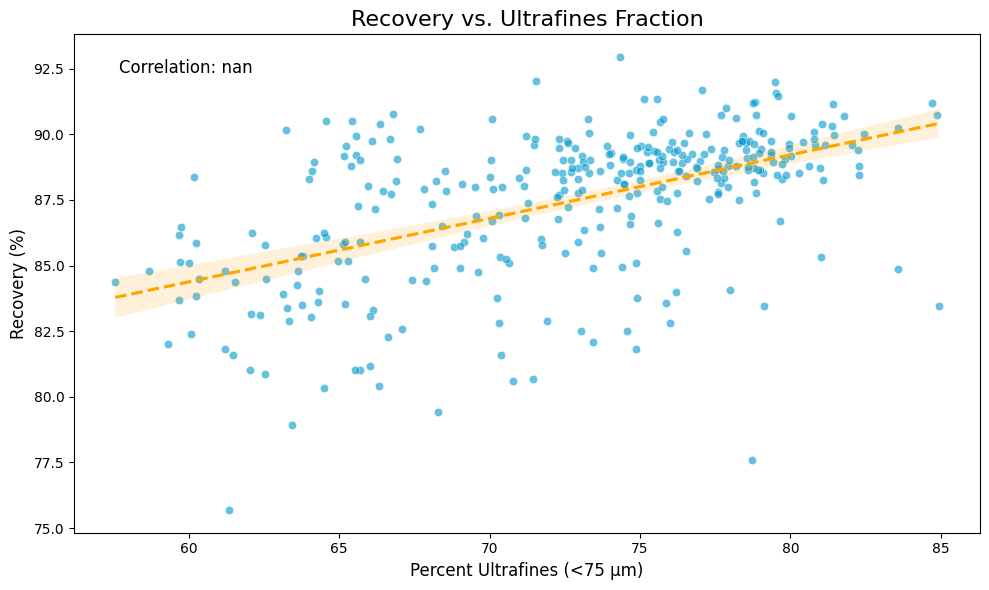

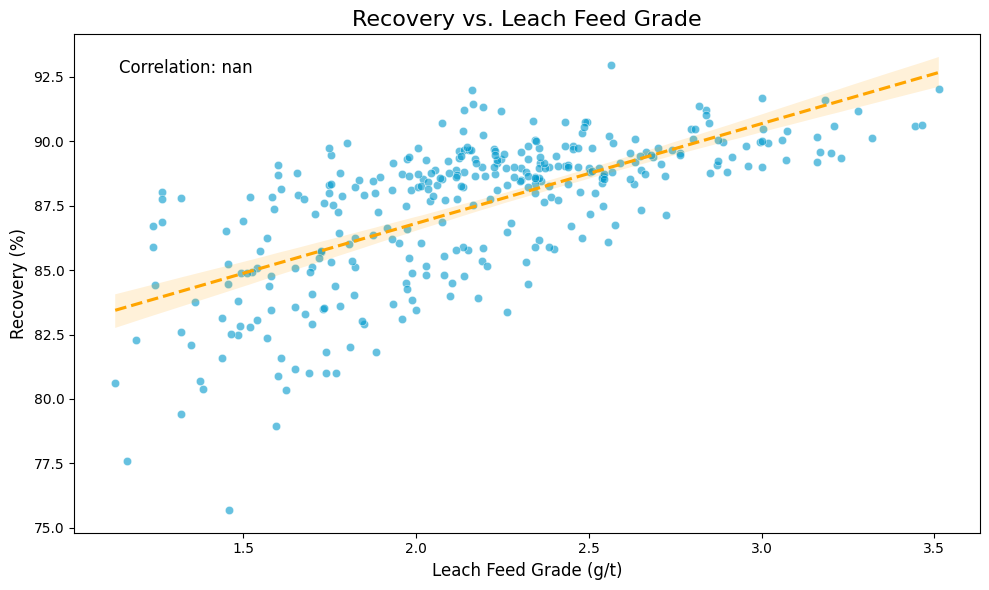

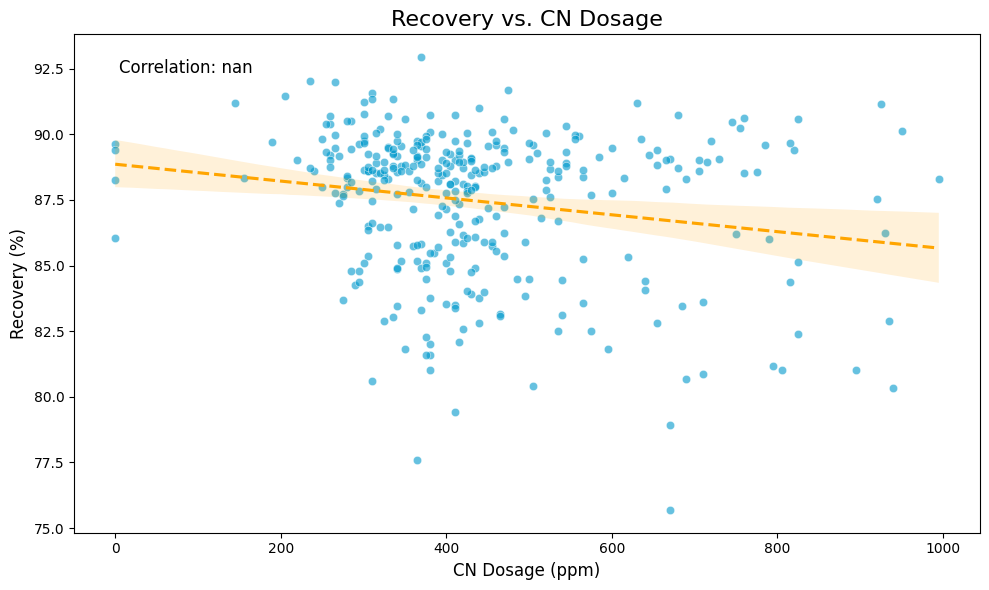

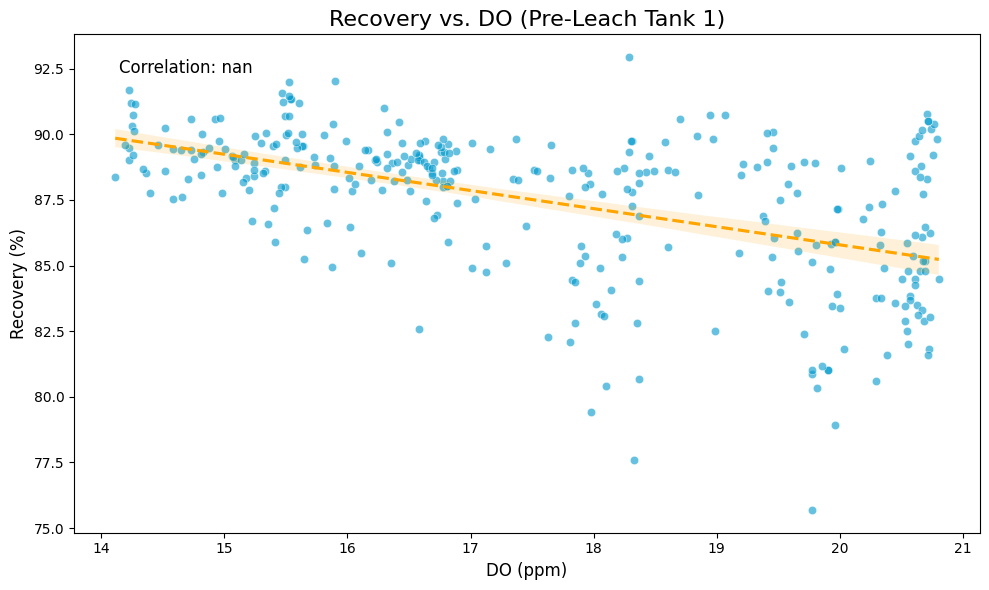

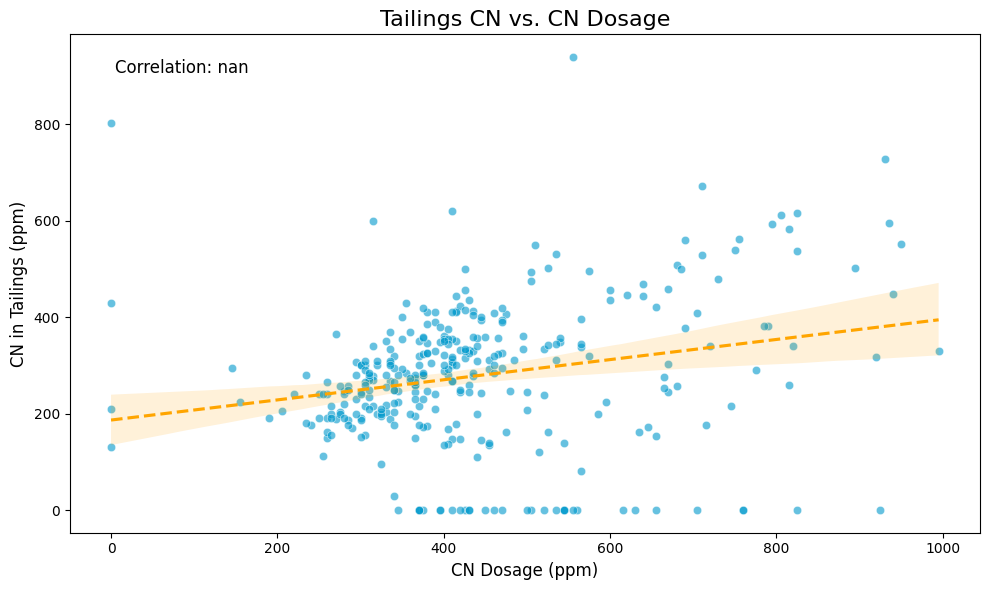

In [55]:
# Calculate average particle size
df["Average_Particle_Size_Microns"] = (
	(df["Leach_Feed_Gt_150um_Day"] / 100 *  coarse_sizing) +
	(df["Leach_Feed_Gt_75um_Day"] / 100 * fine_sizing) +
	(df["Leach_Feed_Lt_75um_Day"] / 100 * ultra_fine_sizing)
	)

# Calculate recovery percentage
df["Recovery_Percentage"] = (
	(df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"]) / 
	df["Cil_Feed_Total_Au_Grams"] * 100
)

# Define herlper function to plot scatter and regression line
def plot_scatter_with_regression(x, y, title="Scatter Plot with Regression Line",
								  xlabel="X-axis", ylabel="Y-axis"):
	"""
	Plot scatter plot with regression line.

	Parameters:
	- x: x-axis data
	- y: y-axis data
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(10, 6))
	sns.scatterplot(x=x, y=y, color='#0099CC', alpha=0.6)
	sns.regplot(x=x, y=y, scatter=False, color='orange', line_kws={"linestyle": "--"})
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.grid(False)

	# Calculate and display correlation coefficient
	corr = np.corrcoef(x, y)[0, 1]
	plt.text(0.05, 0.95, f"Correlation: {corr:.2f}", transform=plt.gca().transAxes,
		  	fontsize=12, verticalalignment='top')
	
	plt.tight_layout()
	plt.show()

# Plot Recovery vs Avg PArticle Size
plot_scatter_with_regression(
	df["Average_Particle_Size_Microns"],
	df["Recovery_Percentage"],
	title="Recovery vs. Avg. Particle Size",
	xlabel="Particle Size (μm)",
	ylabel="Recovery (%)"
)

plot_scatter_with_regression(
	df["Leach_Feed_Lt_75um_Day"],
	df["Recovery_Percentage"],
	title="Recovery vs. Ultrafines Fraction",
	xlabel="Percent Ultrafines (<75 μm)",
	ylabel="Recovery (%)"
)


# Plot Recovery vs Feed Grade
plot_scatter_with_regression(
	df["Leach_Feed_Grade_Au_Gt_Day"],
	df["Recovery_Percentage"],
	title="Recovery vs. Leach Feed Grade",
	xlabel="Leach Feed Grade (g/t)",
	ylabel="Recovery (%)"
)


# Plot Recovery vs CN Dosage
plot_scatter_with_regression(
	df["Leach_Cn_Adds_ppm"],
	df["Recovery_Percentage"],
	title="Recovery vs. CN Dosage",
	xlabel="CN Dosage (ppm)",
	ylabel="Recovery (%)"
)

# Plot Recovery vs DO
plot_scatter_with_regression(
	df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
	df["Recovery_Percentage"],
	title="Recovery vs. DO (Pre-Leach Tank 1)",
	xlabel="DO (ppm)",
	ylabel="Recovery (%)"
)

# Plot CN Dosage vs Tails CN
plot_scatter_with_regression(
	df["Leach_Cn_Adds_ppm"],
	df["Cn_Conc_Tailing_Ppm"],
	title="Tailings CN vs. CN Dosage",
	xlabel="CN Dosage (ppm)",
	ylabel="CN in Tailings (ppm)"
)

In [56]:
df.columns.tolist()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxyge

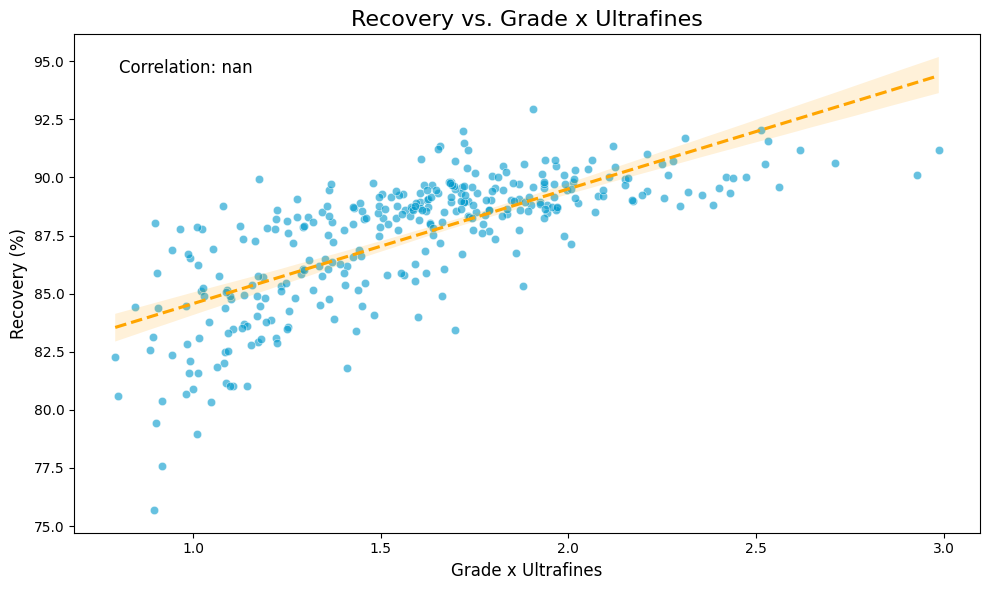

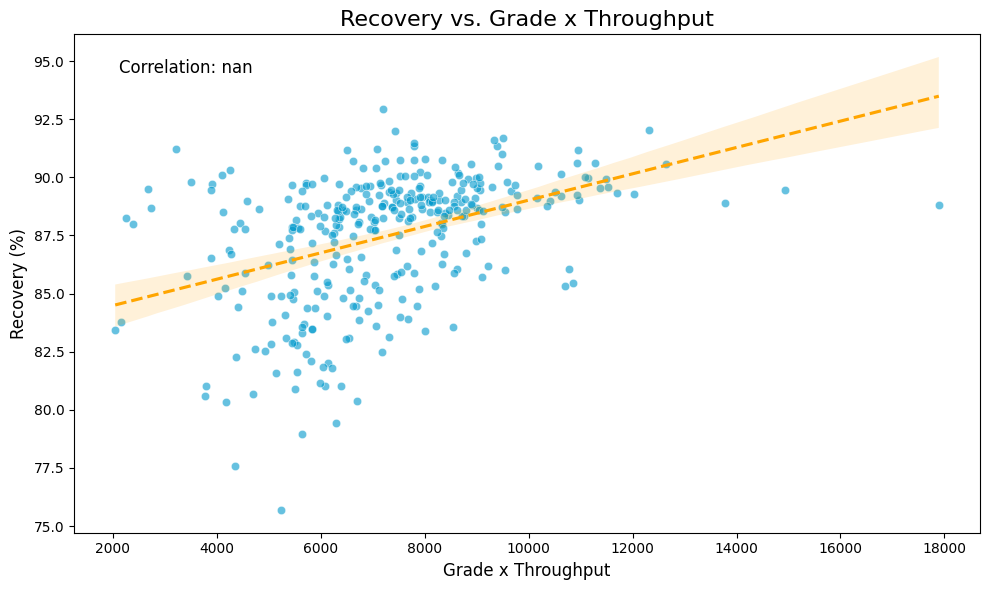

In [57]:
# Plot CN Dosage vs Tails CN
plot_scatter_with_regression(
	df["Grade_x_Ultrafines"],
	df["Recovery_Percentage"],
	title="Recovery vs. Grade x Ultrafines",
	xlabel="Grade x Ultrafines",
	ylabel="Recovery (%)"
)

# Generate a scatter plot with regression line for the interaction term
plot_scatter_with_regression(
	df["Grade_x_Throughput"],
	df["Recovery_Percentage"],
	title="Recovery vs. Grade x Throughput",
	xlabel="Grade x Throughput",
	ylabel="Recovery (%)"
)

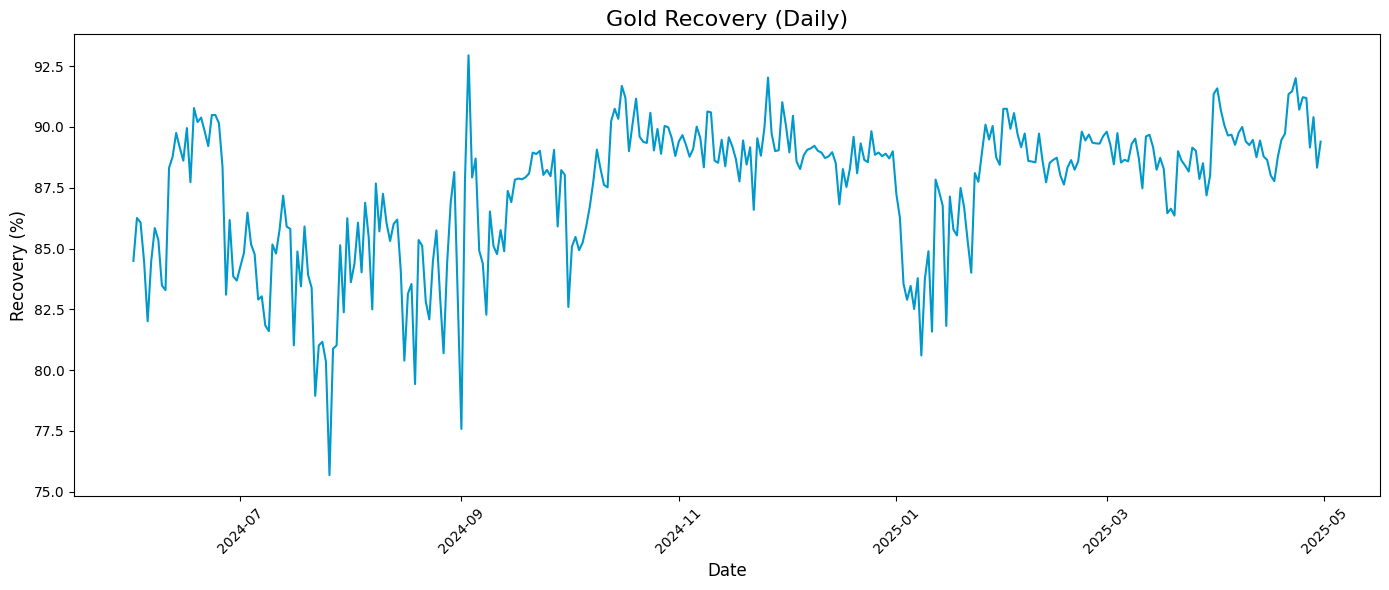

In [58]:
# Plot Daily Gold recovery
def plot_daily_gold_recovery(df, date_col="Date", gold_col="Cil_Feed_Total_Au_Grams",
							  recovery_col="Recovery_Percentage",
							  title="Daily Gold Recovery", xlabel="Date", ylabel="Gold Recovery (%)"):
	"""
	Plot daily gold recovery over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- gold_col: Column name for total gold grams in CIL feed
	- recovery_col: Column name for recovery percentage
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[recovery_col], color='#0099CC')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily gold recovery
plot_daily_gold_recovery(
	df,
	date_col="Date",
	gold_col="Cil_Feed_Total_Au_Grams",
	recovery_col="Recovery_Percentage",
	title="Gold Recovery (Daily)",
	xlabel="Date",
	ylabel="Recovery (%)"
)

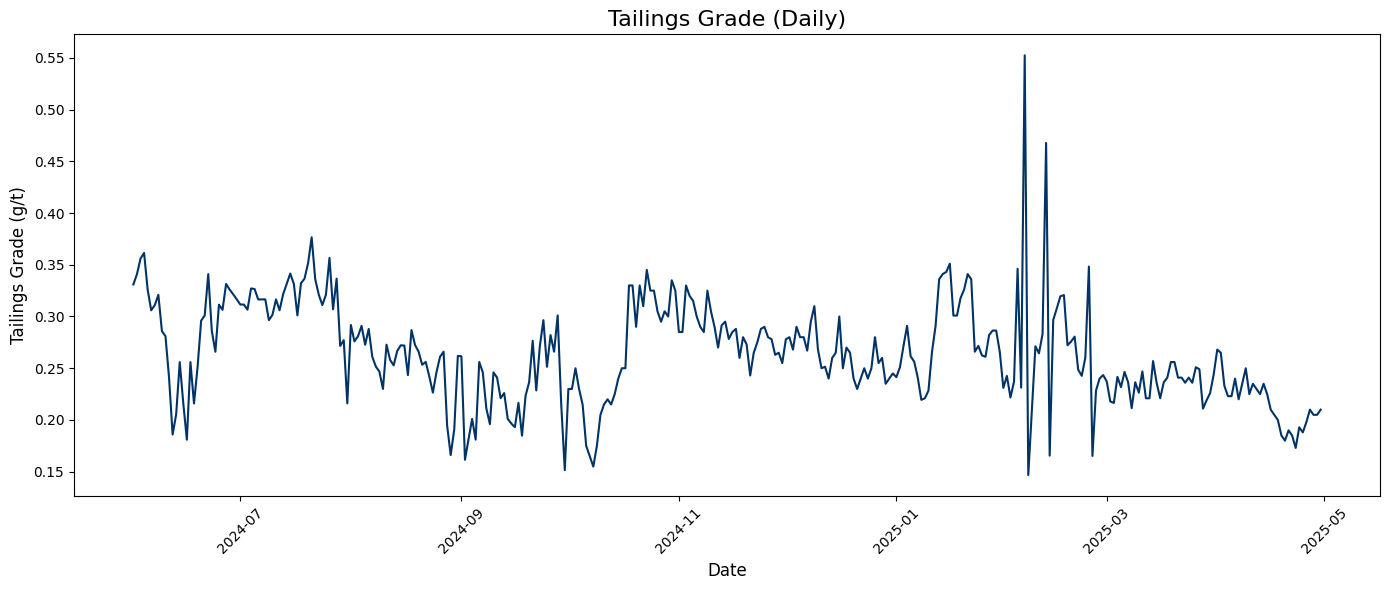

In [59]:
# Plot Daily Tailings grade over time
def plot_daily_tailings_grade(df, date_col="Date", tailings_col="Tailings_Grade_Au_Gt",
							  title="Daily Tailings Grade", xlabel="Date", ylabel="Tailings Grade (g/t)"):
	"""
	Plot daily tailings grade over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- tailings_col: Column name for tailings grade
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[tailings_col], color='#003366')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily tailings grade
plot_daily_tailings_grade(
	df,
	date_col="Date",
	tailings_col="Tailings_Grade_Au_Gt",
	title="Tailings Grade (Daily)",
	xlabel="Date",
	ylabel="Tailings Grade (g/t)"
)

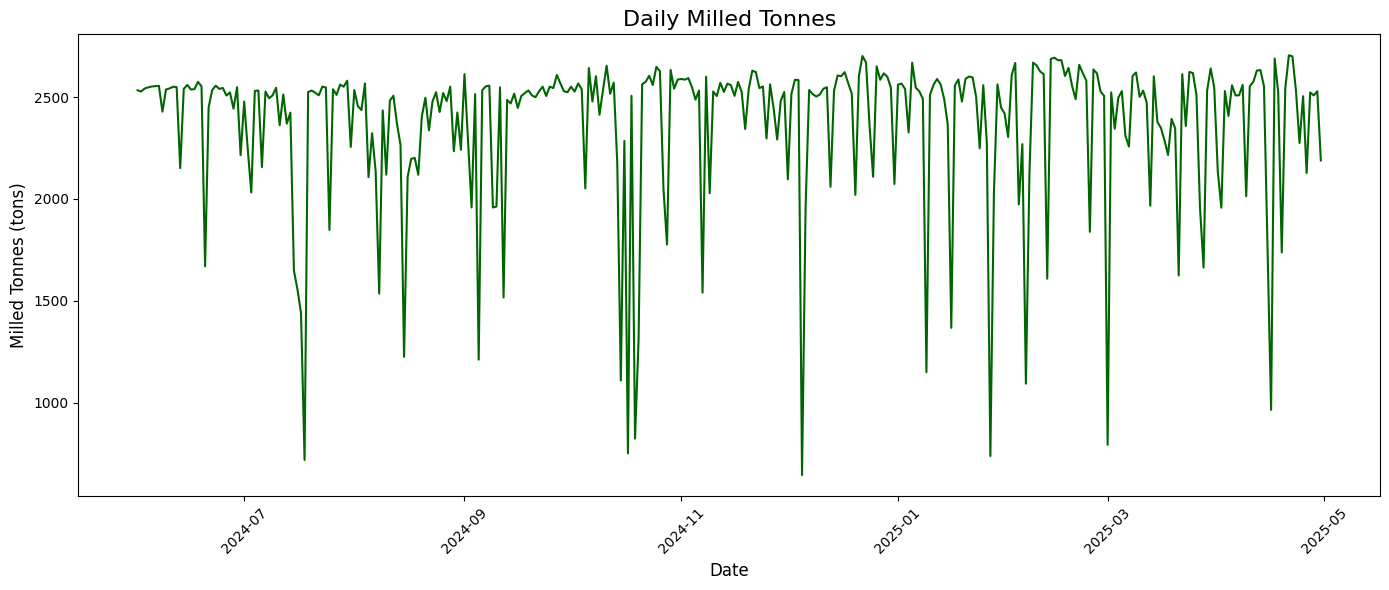

In [60]:
# Plot daily milled tonnes
def plot_daily_milled_tonnes(df, date_col="Date", tonnes_col="Daily_Milledtreated_Tons",
							  title="Daily Milled Tonnes", xlabel="Date", ylabel="Milled Tonnes (tons)"):
	"""
	Plot daily milled tonnes over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- tonnes_col: Column name for daily milled tonnes
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[tonnes_col], color='#006600')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()	

# Plot daily milled tonnes
plot_daily_milled_tonnes(
	df,
	date_col="Date",
	tonnes_col="Daily_Milledtreated_Tons",
	title="Daily Milled Tonnes",
	xlabel="Date",
	ylabel="Milled Tonnes (tons)"
)

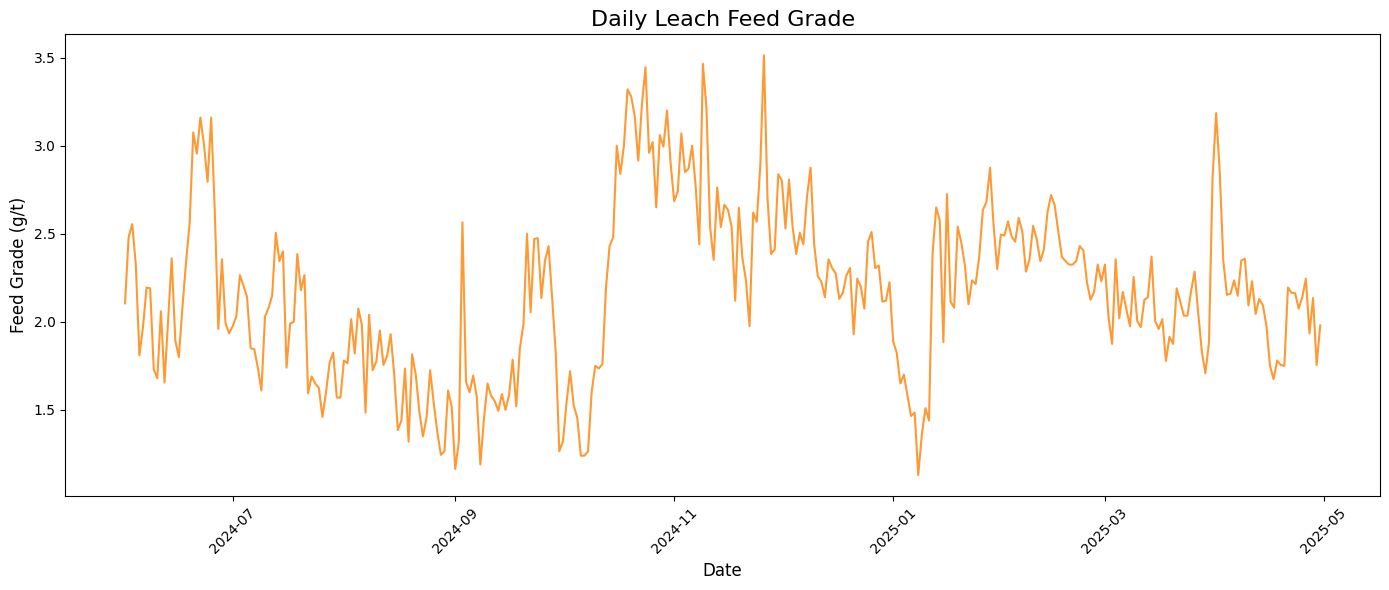

In [61]:
# Plot daily feed grade
def plot_daily_feed_grade(df, date_col="Date", feed_col="Leach_Feed_Grade_Au_Gt_Day",
						  title="Daily Leach Feed Grade", xlabel="Date", ylabel="Feed Grade (g/t)"):
	"""
	Plot daily leach feed grade over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- feed_col: Column name for daily leach feed grade
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[feed_col], color='#FF9933')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily leach feed grade
plot_daily_feed_grade(
	df,
	date_col="Date",
	feed_col="Leach_Feed_Grade_Au_Gt_Day",
	title="Daily Leach Feed Grade",
	xlabel="Date",
	ylabel="Feed Grade (g/t)"
)

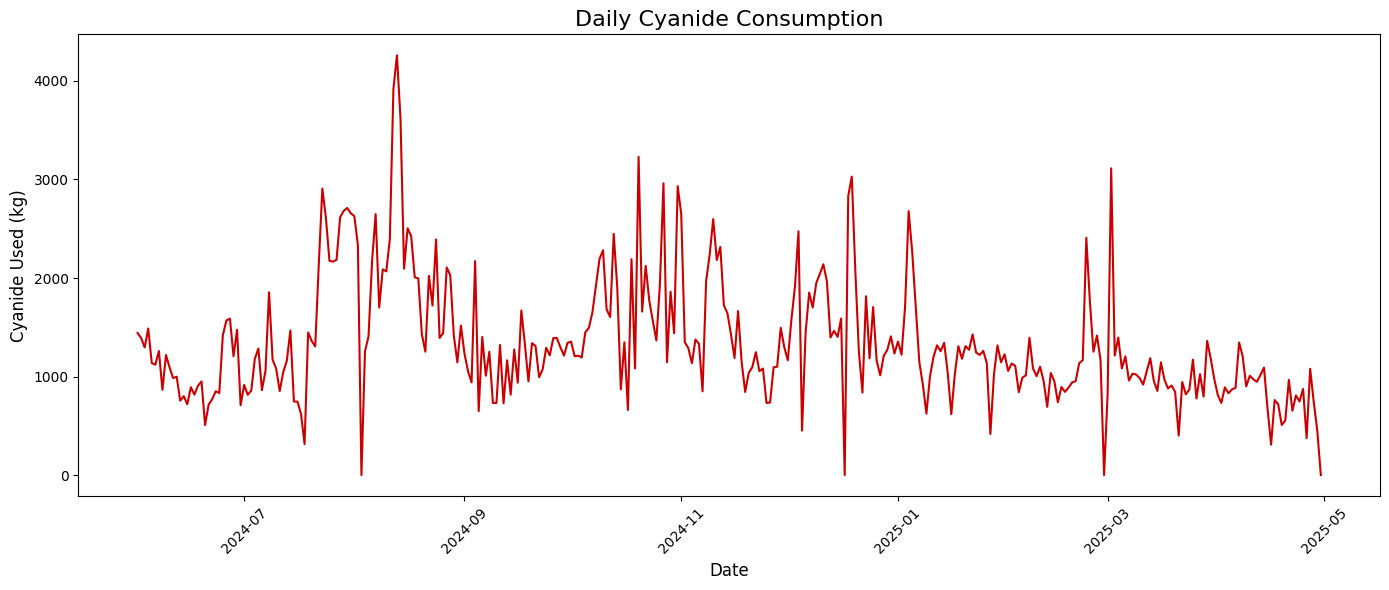

In [62]:
# Plot daily cyanide consumption
def plot_daily_cyanide_consumption(df, date_col="Date", cyanide_col="Estimated_NaCN_Used_Kg_Scaled",
									title="Daily Cyanide Consumption", xlabel="Date", ylabel="Cyanide Used (kg)"):
	"""
	Plot daily cyanide consumption over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- cyanide_col: Column name for daily cyanide consumption
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[cyanide_col], color='#CC0000')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()
# Plot daily cyanide consumption
plot_daily_cyanide_consumption(
	df,
	date_col="Date",
	cyanide_col="Estimated_NaCN_Used_Kg_Scaled",
	title="Daily Cyanide Consumption",
	xlabel="Date",
	ylabel="Cyanide Used (kg)"
)

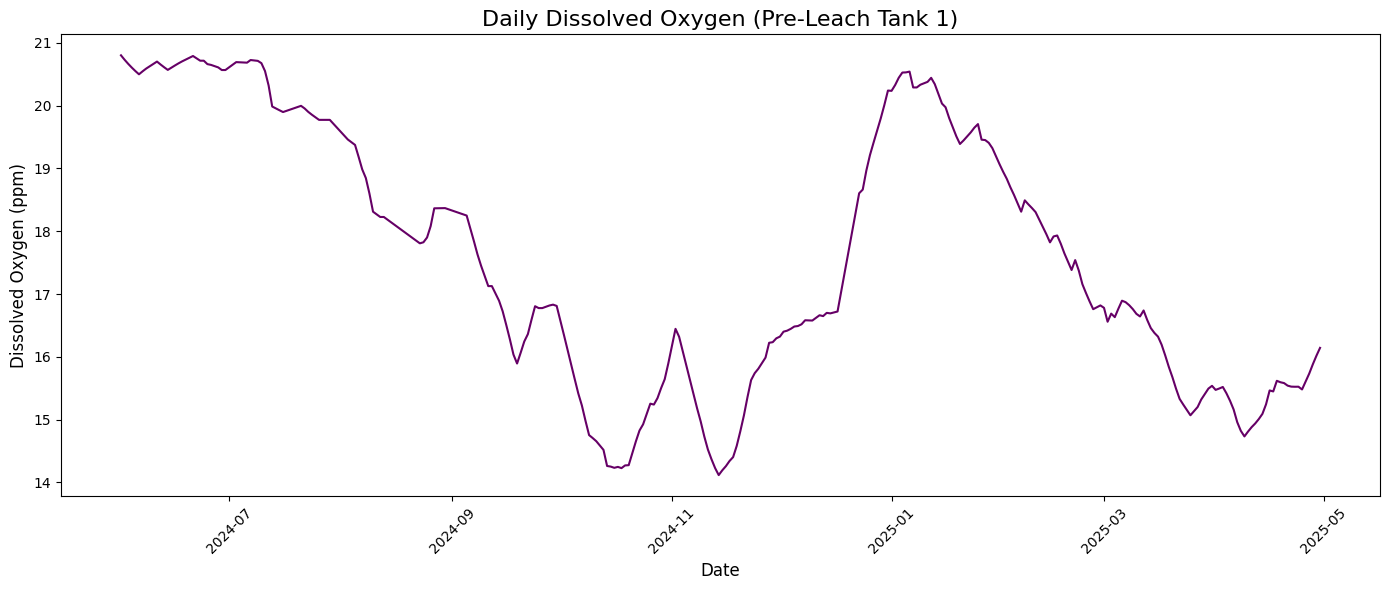

In [63]:
# Plot daily dissolved oxygen
def plot_daily_dissolved_oxygen(df, date_col="Date", do_col="Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
								 title="Daily Dissolved Oxygen (Pre-Leach Tank 1)",
								 xlabel="Date", ylabel="Dissolved Oxygen (ppm)"):
	"""
	Plot daily dissolved oxygen levels over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- do_col: Column name for daily dissolved oxygen levels
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[do_col], color='#660066')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily dissolved oxygen
plot_daily_dissolved_oxygen(
	df,
	date_col="Date",
	do_col="Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	title="Daily Dissolved Oxygen (Pre-Leach Tank 1)",
	xlabel="Date",
	ylabel="Dissolved Oxygen (ppm)"
)

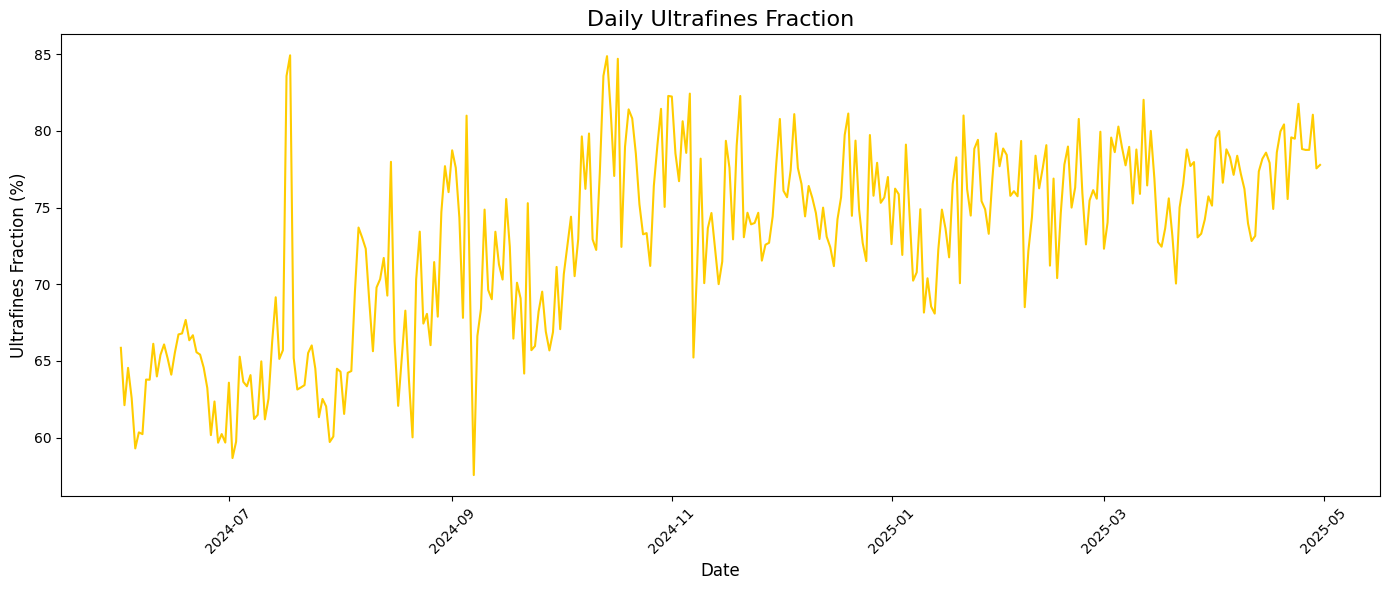

In [64]:
# Plot daily ultrafines fraction
def plot_daily_ultrafines_fraction(df, date_col="Date", ultrafines_col="Leach_Feed_Lt_75um_Day",
							  title="Daily Ultrafines Fraction", xlabel="Date", ylabel="Ultrafines Fraction (%)"):
	"""
	Plot daily ultrafines fraction over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- ultrafines_col: Column name for daily ultrafines fraction
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[ultrafines_col], color='#FFCC00')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily ultrafines fraction
plot_daily_ultrafines_fraction(
	df,
	date_col="Date",
	ultrafines_col="Leach_Feed_Lt_75um_Day",
	title="Daily Ultrafines Fraction",
	xlabel="Date",
	ylabel="Ultrafines Fraction (%)"
)

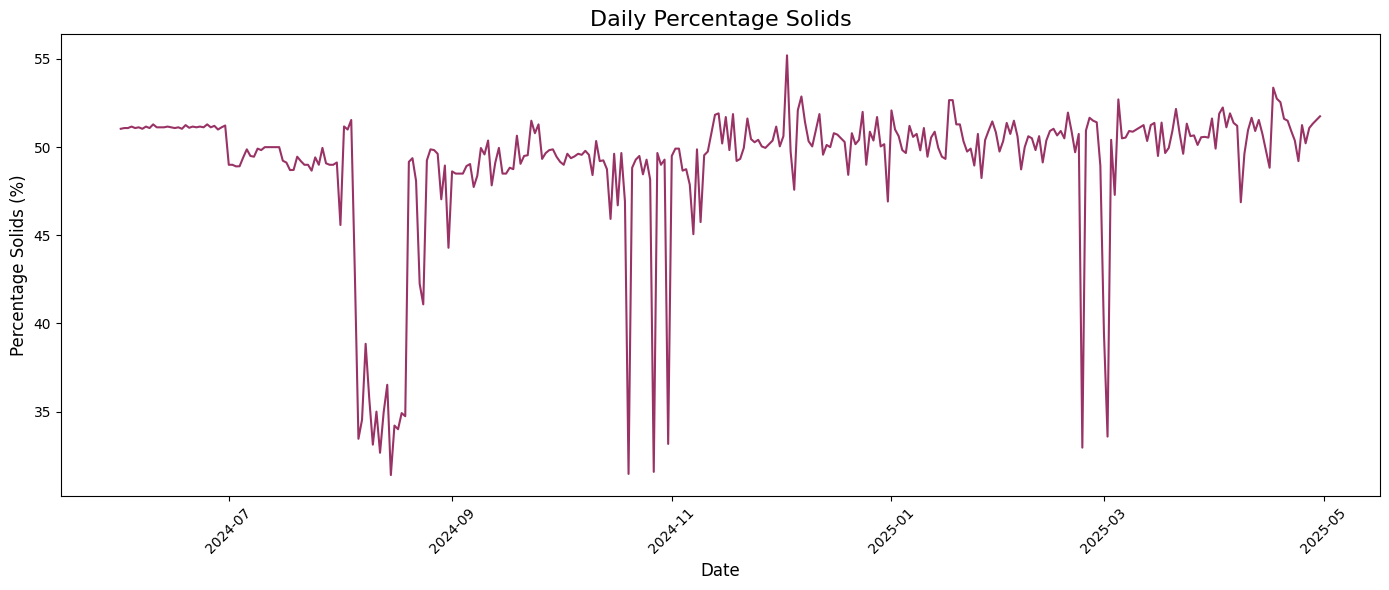

In [65]:
# Plot daily Percentage solids
def plot_daily_percentage_solids(df, date_col="Date", solids_col="Percentage_Solids",
								  title="Daily Percentage Solids", xlabel="Date", ylabel="Percentage Solids (%)"):
	"""
	Plot daily percentage solids over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- solids_col: Column name for daily percentage solids
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[solids_col], color='#993366')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot daily percentage solids
plot_daily_percentage_solids(
	df,
	date_col="Date",
	solids_col="Percentsolids",
	title="Daily Percentage Solids",
	xlabel="Date",
	ylabel="Percentage Solids (%)"
)

In [66]:
# Creating a dataframe containing the Au_Recovery_pct and Ultrafines_Fraction
recovery_ultrafines_df = df[["Date", "Recovery_Percentage", "Leach_Feed_Lt_75um_Day"]].copy()
recovery_ultrafines_df.rename(columns={"Leach_Feed_Lt_75um_Day": "Ultrafines_Fraction"}, inplace=True)

# Export the recovery and ultrafines fraction data to CSV
recovery_ultrafines_df.to_csv("recovery_ultrafines_fraction.csv", index=False)

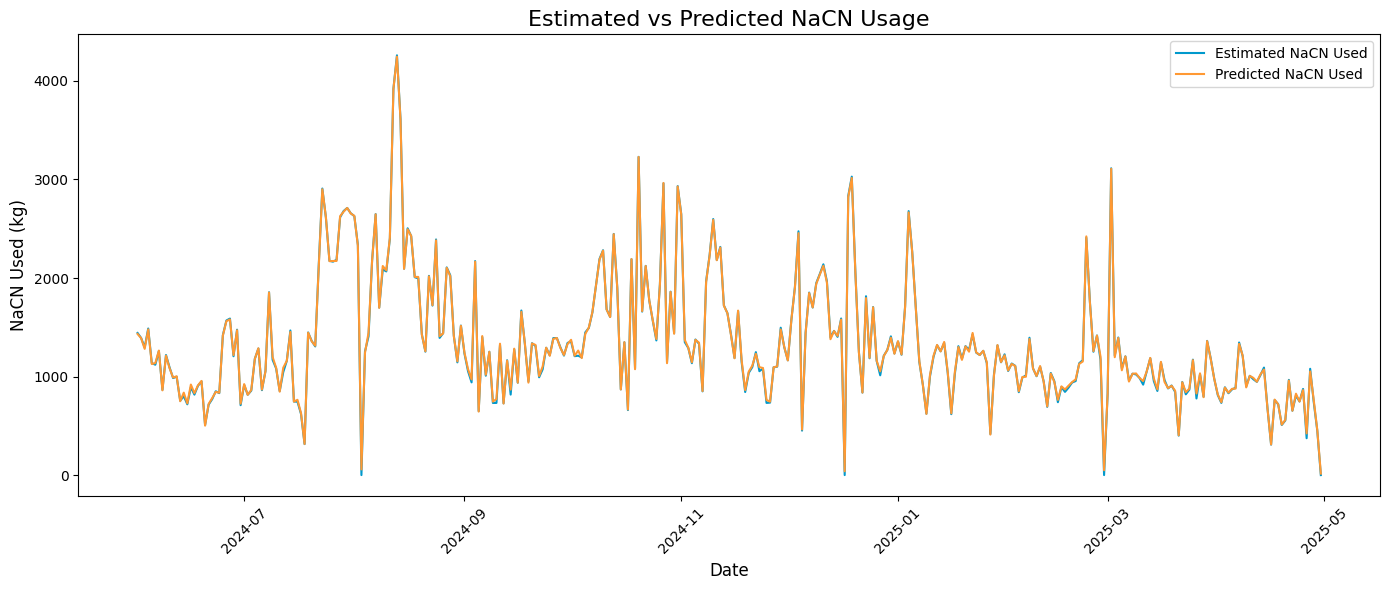

In [67]:
# Compare the Estimated_NaCN_Used_Kg_Scaled and Predicted_NaCN_Used_kg fields in a plot
def plot_estimated_vs_predicted(df, date_col="Date", estimated_col="Estimated_NaCN_Used_Kg_Scaled",
								predicted_col="Predicted_NaCN_Used_kg",
								title="Estimated vs Predicted NaCN Usage",
								xlabel="Date", ylabel="NaCN Used (kg)"):
	"""
	Plot estimated vs predicted NaCN usage over time.

	Parameters:
	- df: DataFrame containing the data
	- date_col: Column name for the date
	- estimated_col: Column name for estimated NaCN usage
	- predicted_col: Column name for predicted NaCN usage
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[estimated_col], label='Estimated NaCN Used', color='#0099CC')
	plt.plot(df[date_col], df[predicted_col], label='Predicted NaCN Used', color='#FF9933')
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.legend()
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# Plot estimated vs predicted NaCN usage
plot_estimated_vs_predicted(
	df,
	date_col="Date",
	estimated_col="Estimated_NaCN_Used_Kg_Scaled",
	predicted_col="Predicted_NaCN_Used_kg",
	title="Estimated vs Predicted NaCN Usage",
	xlabel="Date",
	ylabel="NaCN Used (kg)"
)

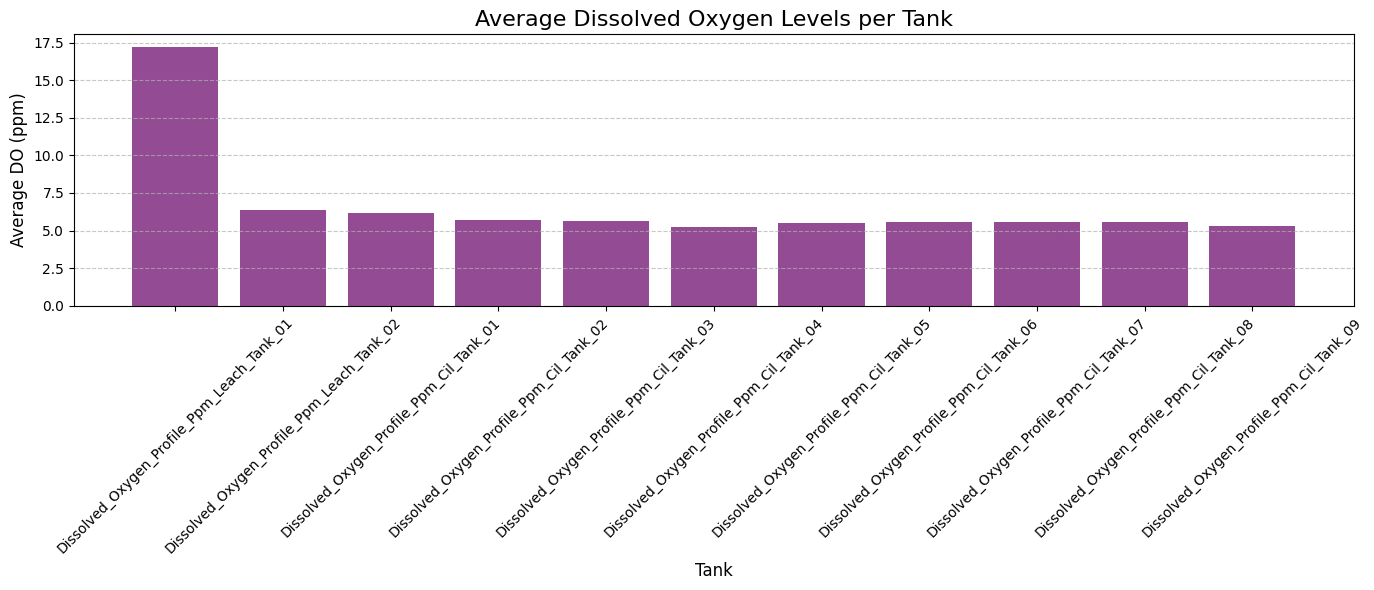

Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01    17.207016
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02     6.374820
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_01       6.152198
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_02       5.685838
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_03       5.626347
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_04       5.237856
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_05       5.533506
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_06       5.579371
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_07       5.591287
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_08       5.539820
Dissolved_Oxygen_Profile_Ppm_Cil_Tank_09       5.332635
dtype: float64

In [68]:
# Plot average DO ppm per tank
def plot_average_do_per_tank(df, do_cols, title="Average DO per Tank",
							 xlabel="Tank", ylabel="Average DO (ppm)"):
	"""
	Plot average dissolved oxygen levels per tank.

	Parameters:
	- df: DataFrame containing the data
	- do_cols: List of column names for each tank's DO levels
	- title, xlabel, ylabel: Plot metadata
	"""
	plt.figure(figsize=(14, 6))
	mean_values = df[do_cols].mean()
	plt.bar(mean_values.index, mean_values.values, color='#660066', alpha=0.7)
	plt.title(title, fontsize=16)
	plt.xlabel(xlabel, fontsize=12)
	plt.ylabel(ylabel, fontsize=12)
	plt.xticks(rotation=45)
	plt.grid(axis='y', linestyle='--', alpha=0.7)
	plt.tight_layout()
	plt.show()
# List of DO columns for each tank
do_columns = [
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_01",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_02",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_03",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_04",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_05",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_06",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_07",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_08",
	"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_09"
]
# Plot average DO levels per tank
plot_average_do_per_tank(
	df,
	do_cols=do_columns,
	title="Average Dissolved Oxygen Levels per Tank",
	xlabel="Tank",
	ylabel="Average DO (ppm)"
)

# Print average DO levels for each tank
average_do_levels = df[do_columns].mean()
average_do_levels

In [69]:
df.columns.tolist()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxyge